# Support Vector Machines (Classification & Regression)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

> **Scope**: the from-scratch twin in `src/models/svm_models.py` implements the **classifier** (`SVC`) only. Regression with `SVR` is shown in §6 using scikit-learn only.

---

## 1. Introduction

### What is a Support Vector Machine?

A Support Vector Machine (SVM) is a **margin-based** supervised learner. Among all boundaries that separate the classes, it picks the one with the **widest possible margin**, the empty band between the two classes. Only the training points on the edge of that band (or inside it) decide where the boundary goes. These are the **support vectors**. The rest of the training data does not enter the final decision function.

Real data is rarely linearly separable, so SVMs add two ingredients:

- **Soft margin**: a penalty `C` lets some points sit inside the band or on the wrong side, trading margin width against training errors.
- **The kernel trick**: a kernel function (linear, polynomial, RBF) computes inner products in a high- or infinite-dimensional feature space without building that space explicitly. A curved boundary in the original features becomes a straight one in the feature space.

**Key characteristics:**
- **Supervised learning**: classification (`SVC`) and regression (`SVR`, §6)
- **Maximum margin**: the boundary is chosen for robustness, not just for fitting the training rows
- **Sparse solution**: only the support vectors appear in the final decision function
- **Kernel-flexible**: linear, polynomial, and RBF boundaries from the same algorithm
- **Scale-sensitive**: distances drive everything, so standardize features (§3)
- **No native probabilities**: the output is a signed distance to the margin; calibrated probabilities need an extra step (§10)

**Historical Context:**
- Vapnik & Lerner (1963): the "generalized portrait" method, a maximum-margin linear classifier
- Boser, Guyon & Vapnik (1992): the kernel trick applied to margin classifiers
- Cortes & Vapnik (1995): "Support-vector networks", the soft-margin formulation used today
- Platt (1998): Sequential Minimal Optimization (SMO), which made training practical
- Chang & Lin (2011): LIBSVM, the library behind scikit-learn's `SVC`

**Main Use Cases:**
- Text and document classification (a strong baseline on sparse, high-dimensional features)
- Image classification with hand-crafted features; bioinformatics (protein and gene classification)
- Handwritten digit recognition (§10 Example 2)
- Small-to-medium tabular problems with a clear margin structure
- One-class SVM for novelty and outlier detection (outside this notebook's scope)

**How it works (simplified):**
1. Pick a boundary `w·x + b = 0` that maximizes the margin `2 / ‖w‖`
2. Allow slack for points that violate the margin, paid for by `C`
3. Optionally map the inputs through a kernel so the boundary can bend
4. Predict with the sign of `f(x)`, which depends only on the support vectors

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.datasets import load_breast_cancer, load_digits, make_blobs, make_circles, make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, mean_squared_error, precision_score,
                             r2_score, recall_score, roc_auc_score, roc_curve)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3


### Visual Intuition: The Maximum Margin

A linear SVM on two separable blobs. A very large `C` makes the margin effectively hard, so the picture shows the pure maximum-margin solution. The support vectors are the circled points.

w rebuilt from the support vectors matches sklearn's coef_: True
Support vectors: 3 of 120 training points
Margin width = 2 / ||w|| = 2.505


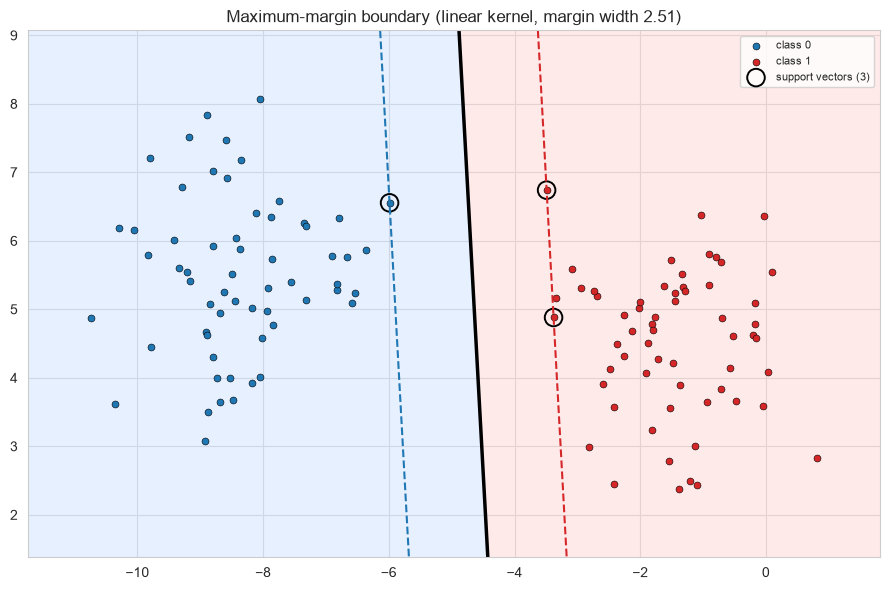


💡 Only the circled points define the boundary. Move any other point (keeping it outside the
   margin) and the boundary does not change. That is the sparsity of the SVM solution.


In [2]:
def plot_margins(ax, model, X, y, title):
    # Decision boundary (value 0), margin lines (value -1 and +1), and support vectors.
    # Works for any binary SVM exposing decision_function and support_vectors_
    # (scikit-learn's SVC and the scratch SVMClassifierScratch alike).
    pad = 1.0
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300),
    )
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    lo, hi = min(Z.min(), 0.0) - 1.0, max(Z.max(), 0.0) + 1.0
    ax.contourf(xx, yy, Z, levels=[lo, 0.0, hi], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[-1.0, 0.0, 1.0], colors=["#1f77b4", "black", "#d62728"],
               linestyles=["--", "-", "--"], linewidths=[1.5, 2.5, 1.5])
    for label, color in zip(np.unique(y), ["#1f77b4", "#d62728"]):
        ax.scatter(X[y == label, 0], X[y == label, 1], c=color, s=25, edgecolors="k",
                   linewidths=0.4, label=f"class {label}")
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=160, facecolors="none", edgecolors="k", linewidths=1.4,
               label=f"support vectors ({len(sv)})")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")


X_blob, y_blob = make_blobs(n_samples=120, centers=2, cluster_std=1.1, random_state=7)
svm_hard = SVC(kernel="linear", C=1e3).fit(X_blob, y_blob)   # very large C: effectively hard margin

w_from_duals = svm_hard.dual_coef_[0] @ svm_hard.support_vectors_   # w = sum_i alpha_i * y_i * x_i
print(f"w rebuilt from the support vectors matches sklearn's coef_: "
      f"{np.allclose(w_from_duals, svm_hard.coef_[0])}")

margin_width = 2.0 / np.linalg.norm(w_from_duals)
print(f"Support vectors: {len(svm_hard.support_)} of {len(X_blob)} training points")
print(f"Margin width = 2 / ||w|| = {margin_width:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
plot_margins(ax, svm_hard, X_blob, y_blob,
             f"Maximum-margin boundary (linear kernel, margin width {margin_width:.2f})")
plt.tight_layout()
plt.show()

print("\n💡 Only the circled points define the boundary. Move any other point (keeping it outside the")
print("   margin) and the boundary does not change. That is the sparsity of the SVM solution.")

---

## 2. Theory & Mathematics

### Core Concept: Maximum Margin

Write the boundary as $f(x) = w^\top x + b$ and the labels as $y \in \{-1, +1\}$. A point is classified correctly with margin when $y_i f(x_i) \ge 1$. The two supporting hyperplanes $w^\top x + b = \pm 1$ are separated by a gap of $\frac{2}{\|w\|}$, so **maximizing the margin is the same as minimizing $\|w\|$**:

$$\min_{w,b} \; \frac{1}{2}\|w\|^2 \qquad \text{s.t.} \qquad y_i\,(w^\top x_i + b) \ge 1 \quad \forall i$$

This is the **hard-margin** SVM. It has a solution only when the classes are perfectly separable.

### Soft Margin and the Hinge Loss

Real data needs slack variables $\xi_i \ge 0$ that allow violations, paid for by the penalty $C$:

$$\min_{w,b,\xi} \; \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i \qquad \text{s.t.} \qquad y_i\,(w^\top x_i + b) \ge 1 - \xi_i, \;\; \xi_i \ge 0$$

Eliminating $\xi$ gives the equivalent unconstrained form with the **hinge loss**:

$$\min_{w,b} \; \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\max\big(0,\; 1 - y_i f(x_i)\big)$$

- **Small C**: violations are cheap, so the margin stays wide and some training points are misclassified
- **Large C**: violations are expensive, so the boundary bends to fit more training points and the margin narrows

The hinge loss is exactly zero for any point with $y_i f(x_i) \ge 1$. Points safely beyond the margin cost nothing, which is why the solution depends on only a few points.

### The Dual Problem and Support Vectors

Lagrange duality turns the problem into one over coefficients $\alpha_i$:

$$\max_{\alpha} \; \sum_{i}\alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j\,y_i y_j\,K(x_i, x_j) \qquad \text{s.t.} \qquad \sum_i \alpha_i y_i = 0, \;\; 0 \le \alpha_i \le C$$

where $K$ is the kernel. The decision function is

$$f(x) = \sum_{i:\,\alpha_i > 0} \alpha_i\, y_i\, K(x_i, x) + b$$

The KKT conditions give three regimes:

| Coefficient | Where the point sits | Role |
|---|---|---|
| $\alpha_i = 0$ | Outside the margin, correctly classified | Irrelevant to the model |
| $0 < \alpha_i < C$ | Exactly on the margin ($y_i f(x_i) = 1$) | Support vector |
| $\alpha_i = C$ | Inside the margin or misclassified | Support vector (bounded) |

Only the support vectors (rows with $\alpha_i > 0$) appear in the sum. In the linear case the weight vector is recovered as $w = \sum_i \alpha_i y_i x_i$.

### The Kernel Trick

A kernel $K(x, x') = \phi(x)^\top \phi(x')$ computes an inner product in a feature space $\phi$ without constructing $\phi(x)$. The common kernels:

- **Linear**: $K(x, x') = x^\top x'$, a straight boundary in the original features
- **Polynomial**: $K(x, x') = (\gamma\, x^\top x' + r)^d$, curved boundaries of degree $d$
- **RBF (Gaussian)**: $K(x, x') = \exp\big(-\gamma\|x - x'\|^2\big)$, an infinite-dimensional feature space and the workhorse kernel

**gamma** is the inverse width of the RBF. Small $\gamma$: each support vector influences a broad region, giving smooth boundaries. Large $\gamma$: influence is confined to a tiny radius around each support vector, so the boundary breaks into islands, which is memorization. §7 shows this directly.

### Why Scaling Matters

Every kernel is a function of distances or inner products. A feature measured in the thousands dominates $\|x - x'\|^2$ and drowns out a feature measured in fractions. Standardize inside a pipeline (§3).

### Computational Complexity

| Operation | Cost | Notes |
|---|---|---|
| Training | roughly $O(n^2)$ to $O(n^3)$ in practice | libSVM-style SMO solvers; depends on the data and on $C$ |
| Kernel memory | $O(n^2)$ if the full Gram matrix is stored | libSVM caches kernel rows; the scratch twin stores the full matrix |
| Prediction | $O(n_{sv} \cdot d)$ per sample | each support vector is compared with the input |
| Model size | $O(n_{sv} \cdot d)$ | the support vectors must be stored |

### SVM vs Logistic Regression (preview of §11)

Both are linear classifiers in their base form. Logistic regression minimizes log loss and outputs probabilities. The SVM minimizes hinge loss, outputs a signed distance to the margin, and ignores points beyond the margin.

### Loss Functions: Why the Hinge?

The margin $m = y\,f(x)$ is positive when a point is on the correct side. The 0-1 loss is what we ultimately care about, but it is not convex, so optimizers cannot use it directly. The hinge loss is a convex upper bound on it, and it is exactly zero once a point clears the margin.

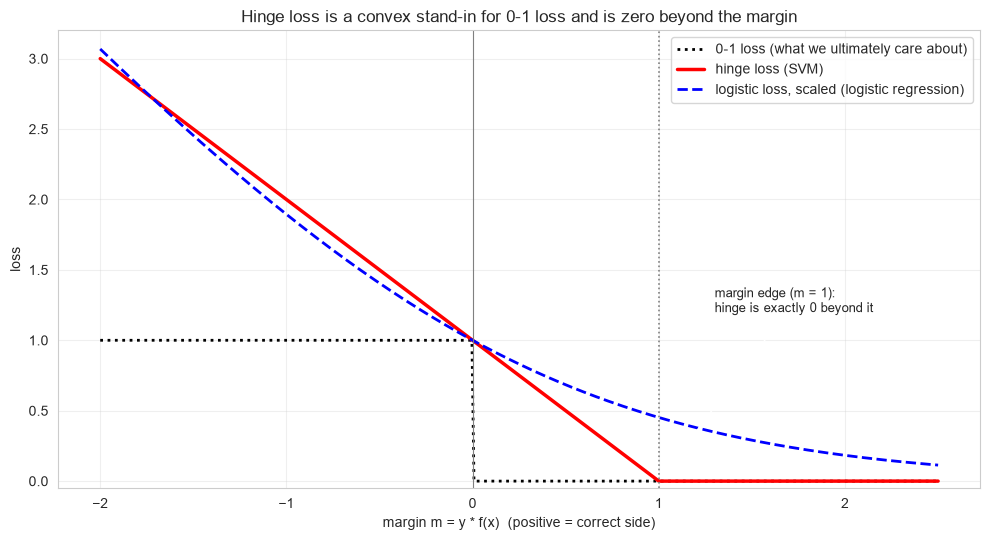

 margin m |  0-1 |  hinge | logistic (scaled)
     -1.0 |    1 |   2.00 |              1.89
     +0.0 |    1 |   1.00 |              1.00
     +0.5 |    0 |   0.50 |              0.68
     +1.0 |    0 |   0.00 |              0.45
     +2.0 |    0 |   0.00 |              0.18

💡 Points with m >= 1 contribute nothing to the hinge loss. The support vectors are the points that do.


In [3]:
margins = np.linspace(-2.0, 2.5, 400)             # m = y * f(x): positive means correct side
zero_one = (margins <= 0).astype(float)            # 1 when misclassified (or on the boundary)
hinge = np.maximum(0.0, 1.0 - margins)              # SVM loss
logistic = np.log1p(np.exp(-margins)) / np.log(2)   # logistic loss, scaled to equal 1 at m = 0

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(margins, zero_one, "k:", lw=2, label="0-1 loss (what we ultimately care about)")
ax.plot(margins, hinge, "r-", lw=2.5, label="hinge loss (SVM)")
ax.plot(margins, logistic, "b--", lw=2, label="logistic loss, scaled (logistic regression)")
ax.axvline(1.0, color="gray", ls=":", lw=1.2)
ax.axvline(0.0, color="gray", ls="-", lw=0.8)
ax.annotate("margin edge (m = 1):\nhinge is exactly 0 beyond it", xy=(1.0, 0.0), xytext=(1.3, 1.2),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.set_xlabel("margin m = y * f(x)  (positive = correct side)")
ax.set_ylabel("loss")
ax.set_title("Hinge loss is a convex stand-in for 0-1 loss and is zero beyond the margin")
ax.set_ylim(-0.05, 3.2)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"{'margin m':>9s} | {'0-1':>4s} | {'hinge':>6s} | {'logistic (scaled)':>17s}")
for m in [-1.0, 0.0, 0.5, 1.0, 2.0]:
    lg = np.log1p(np.exp(-m)) / np.log(2)
    print(f"{m:+9.1f} | {float(m <= 0):4.0f} | {max(0.0, 1.0 - m):6.2f} | {lg:17.2f}")
print("\n💡 Points with m >= 1 contribute nothing to the hinge loss. The support vectors are the points that do.")

### Visualizing C: The Soft Margin in Action

Overlapping blobs cannot be separated perfectly. The same linear kernel at three values of `C` shows the trade-off between margin width and training errors.

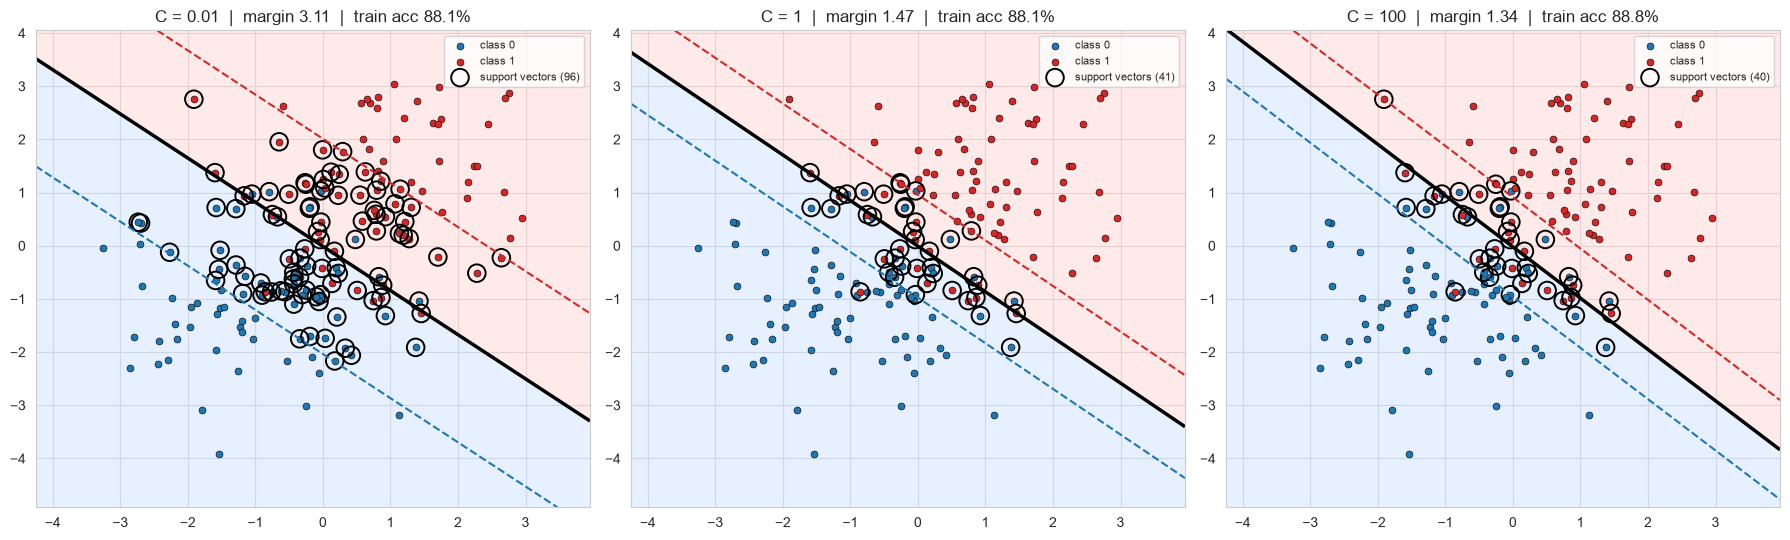

       C | margin width | support vectors | train acc
    0.01 |        3.115 |              96 |     0.881
       1 |        1.468 |              41 |     0.881
     100 |        1.345 |              40 |     0.887

💡 Small C favors a wide band that tolerates violations. Large C narrows the band so that
   it fits more training points. The same knob that controls fit later controls overfitting.


In [4]:
X_ov, y_ov = make_blobs(n_samples=160, centers=[(-1.0, -1.0), (1.0, 1.0)], cluster_std=1.1,
                        random_state=11)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
rows_c = []
for ax, C_val in zip(axes, [0.01, 1.0, 100.0]):
    svc_c = SVC(kernel="linear", C=C_val).fit(X_ov, y_ov)
    width_c = 2.0 / np.linalg.norm(svc_c.coef_[0])
    train_acc_c = svc_c.score(X_ov, y_ov)
    rows_c.append((C_val, width_c, len(svc_c.support_), train_acc_c))
    plot_margins(ax, svc_c, X_ov, y_ov,
                 f"C = {C_val:g}  |  margin {width_c:.2f}  |  train acc {train_acc_c:.1%}")
plt.tight_layout()
plt.show()

print(f"{'C':>8s} | {'margin width':>12s} | {'support vectors':>15s} | {'train acc':>9s}")
for C_val, width_c, n_sv_c, acc_c in rows_c:
    print(f"{C_val:8g} | {width_c:12.3f} | {n_sv_c:15d} | {acc_c:9.3f}")
print("\n💡 Small C favors a wide band that tolerates violations. Large C narrows the band so that")
print("   it fits more training points. The same knob that controls fit later controls overfitting.")

### The Kernel Trick Visualized

Concentric rings cannot be split by a straight line in the raw $(x, y)$ plane. Three ways around it:
1. **Linear SVM on raw coordinates**: no help
2. **Linear SVM after an explicit feature**: add $r^2 = x^2 + y^2$ and the rings become separable by one threshold
3. **RBF SVM**: reaches a similarly separable space implicitly, without anyone designing the feature

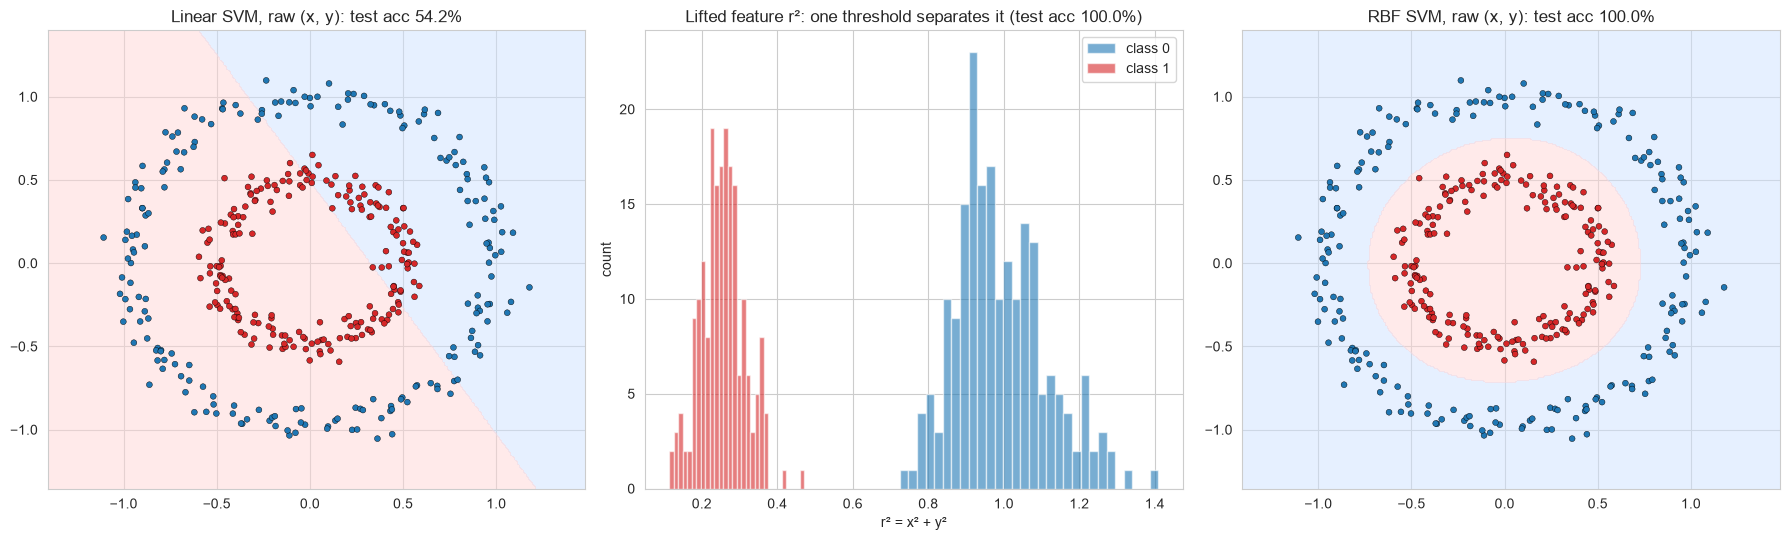

Linear SVM, raw coordinates:           test accuracy 54.2%
Linear SVM, plus explicit r^2 feature: test accuracy 100.0%
RBF SVM, raw coordinates (implicit):   test accuracy 100.0%

💡 A straight line in the raw plane cannot wrap a ring. The explicit lift makes the rings separable,
   and the RBF kernel reaches a similarly separable space implicitly. You never design that feature by hand.


In [5]:
def plot_regions(ax, model, X, y, title):
    # Predicted-label regions of a 2-D classifier fitted on raw coordinates (labels 0 and 1).
    pad = 0.3
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    ax.scatter(X[:, 0], X[:, 1], c=np.where(y == 1, "#d62728", "#1f77b4"), s=18,
               edgecolors="k", linewidths=0.3)
    ax.set_title(title)


def lift(X):
    # Explicit feature map: append r^2 = x^2 + y^2
    return np.c_[X, (X ** 2).sum(axis=1)]


X_circ, y_circ = make_circles(n_samples=400, factor=0.5, noise=0.06, random_state=42)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_circ, y_circ, test_size=0.3, stratify=y_circ,
                                              random_state=42)

linear_raw = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="linear", C=1.0))])
linear_raw.fit(Xc_tr, yc_tr)
linear_lift = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="linear", C=1.0))])
linear_lift.fit(lift(Xc_tr), yc_tr)
rbf_raw = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))])
rbf_raw.fit(Xc_tr, yc_tr)

acc_raw = linear_raw.score(Xc_te, yc_te)
acc_lift = linear_lift.score(lift(Xc_te), yc_te)
acc_rbf = rbf_raw.score(Xc_te, yc_te)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_regions(axes[0], linear_raw, X_circ, y_circ, f"Linear SVM, raw (x, y): test acc {acc_raw:.1%}")
r2_all = lift(X_circ)[:, 2]
axes[1].hist(r2_all[y_circ == 0], bins=30, alpha=0.6, color="#1f77b4", label="class 0")
axes[1].hist(r2_all[y_circ == 1], bins=30, alpha=0.6, color="#d62728", label="class 1")
axes[1].set_xlabel("r² = x² + y²")
axes[1].set_ylabel("count")
axes[1].set_title(f"Lifted feature r²: one threshold separates it (test acc {acc_lift:.1%})")
axes[1].legend()
plot_regions(axes[2], rbf_raw, X_circ, y_circ, f"RBF SVM, raw (x, y): test acc {acc_rbf:.1%}")
plt.tight_layout()
plt.show()

print(f"Linear SVM, raw coordinates:           test accuracy {acc_raw:.1%}")
print(f"Linear SVM, plus explicit r^2 feature: test accuracy {acc_lift:.1%}")
print(f"RBF SVM, raw coordinates (implicit):   test accuracy {acc_rbf:.1%}")
print("\n💡 A straight line in the raw plane cannot wrap a ring. The explicit lift makes the rings separable,")
print("   and the RBF kernel reaches a similarly separable space implicitly. You never design that feature by hand.")

---

## 3. Assumptions & Requirements

SVMs make few distributional assumptions, but they are **geometry-sensitive**. Most real failures come from scale, kernel choice, and the two hyperparameters, not from the theory.

### Critical Assumptions

#### ✅ 1. **Feature Scaling Is Mandatory**
- Kernels and margins are distance- and inner-product-based. A feature with a large numeric range dominates every distance
- **Test**: compare per-feature ranges and the share of squared distance each feature contributes (demo below)
- **Fix**: `StandardScaler` inside a `Pipeline`, fitted on training data only

#### ✅ 2. **Complete Data (No Missing Values)**
- `SVC` raises on NaN values. Impute first, inside the pipeline
- **Fix**: `SimpleImputer` (median for skewed features) before the scaler

#### ✅ 3. **Independent, Identically Distributed Rows**
- The margin logic and generalization guarantees assume training and test rows come from the same distribution
- **Violation fix**: time-aware splits for temporal data; group-aware splits for clustered data

#### ✅ 4. **A Kernel That Matches the Geometry**
- A linear kernel assumes a (soft) linear separation. RBF assumes only local smoothness, controlled by $\gamma$
- **Test**: compare a linear and an RBF model under cross-validation. A large gap says the boundary is curved
- **Fix**: choose the kernel, then tune $C$ and $\gamma$ (§7)

#### ✅ 5. **Manageable Sample Size**
- Kernel training scales between $O(n^2)$ and $O(n^3)$, and the solver needs an $n \times n$ kernel matrix. Practical RBF ceilings are in the tens of thousands of rows, depending on hardware
- **Fix**: `LinearSVC` or `SGDClassifier(loss="hinge")` for large linear problems; Nyström features for large non-linear ones (§9)

### When Assumptions Are Violated

| Violation | Symptom | Fix |
|---|---|---|
| Unscaled features | The boundary ignores small-range features; RBF distances follow one column | `StandardScaler` in a `Pipeline` |
| $\gamma$ too large | Islands around single points; high training accuracy, weaker test accuracy | Smaller $\gamma$; grid search |
| $C$ too large | A narrow margin that memorizes noise | Smaller $C$; grid search |
| Linear kernel on curved classes | Accuracy stuck near the linear ceiling | RBF or polynomial kernel, or explicit features |
| Very large $n$ with an RBF kernel | Long training, high memory | `LinearSVC`, SGD, or approximate kernels |

### Data Requirements

- **Sample size**: a few dozen rows per class is a practical minimum. RBF needs more to pin the boundary down
- **Feature scaling**: required (see above)
- **Categorical variables**: one-hot encode. Ordinal codes with arbitrary spacing distort distances
- **Missing values**: impute before fitting
- **Class balance**: affects the fit. Use `class_weight='balanced'` or tune the decision threshold

### Key Differences from Logistic Regression

| Aspect | Logistic Regression | SVM |
|---|---|---|
| Loss | Log loss (cross-entropy) | Hinge loss |
| Output | Probability | Signed distance to the margin |
| Points that matter | All of them (weighted) | Support vectors only |
| Probabilities | Native | Needs Platt scaling or calibration |
| Non-linear boundaries | Needs transforms | Kernels built in |

> **The demo that follows** shows the scaling trap on real data: the same RBF SVM with and without standardization, and how much of the squared distance one feature controls.

Feature ranges (3 of 30):
                     min       max
mean smoothness    0.053     0.163
mean concavity     0.000     0.427
mean area        143.500  2501.000

Largest single-feature share of squared distance (average over random training pairs):
  raw:          'worst area' contributes 64.1%
  standardized: the same feature contributes 2.8%


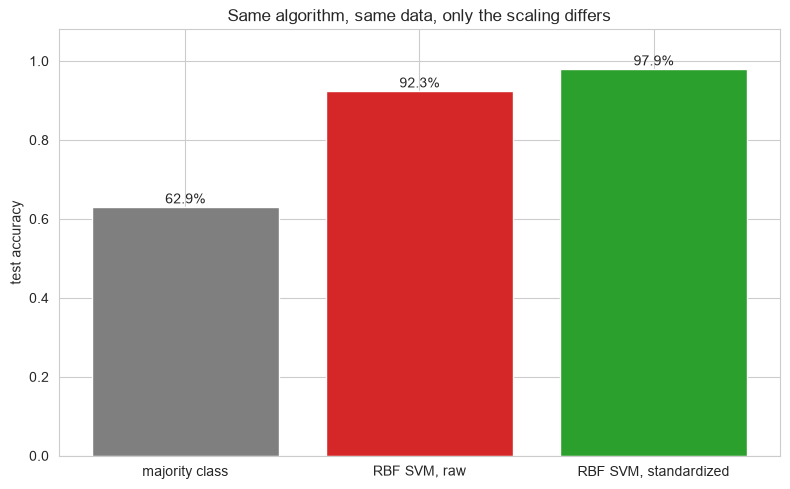


Test accuracy: majority baseline 62.9% | raw 92.3% | standardized 97.9%

💡 Without scaling, distances are dominated by the largest-range columns. Read the share printed above.
   The fix is one line, and it belongs inside the Pipeline so the scaler only ever sees training data.


In [6]:
bc = load_breast_cancer()
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(bc.data, bc.target, test_size=0.25,
                                              stratify=bc.target, random_state=42)

# 1) How different are the feature ranges?
ranges = pd.DataFrame({"min": bc.data.min(axis=0), "max": bc.data.max(axis=0)},
                      index=bc.feature_names)
print("Feature ranges (3 of 30):")
print(ranges.loc[["mean smoothness", "mean concavity", "mean area"]].round(3).to_string())

# 2) Share of squared distance contributed by each feature, raw vs standardized
scaler_b = StandardScaler().fit(Xb_tr)
Xb_tr_s = scaler_b.transform(Xb_tr)
rng_s = np.random.default_rng(0)
ia = rng_s.integers(0, len(Xb_tr), 500)
ib = rng_s.integers(0, len(Xb_tr), 500)


def distance_share(A, B):
    # Average fraction of squared Euclidean distance coming from each feature
    sq = (A - B) ** 2
    return (sq / (sq.sum(axis=1, keepdims=True) + 1e-12)).mean(axis=0)


share_raw = distance_share(Xb_tr[ia], Xb_tr[ib])
share_std = distance_share(Xb_tr_s[ia], Xb_tr_s[ib])
top_raw = int(np.argmax(share_raw))
print("\nLargest single-feature share of squared distance (average over random training pairs):")
print(f"  raw:          '{bc.feature_names[top_raw]}' contributes {share_raw[top_raw]:.1%}")
print(f"  standardized: the same feature contributes {share_std[top_raw]:.1%}")

# 3) The accuracy consequence: same RBF SVM, with and without the scaler
raw_svc_b = SVC(kernel="rbf", C=1.0, gamma="scale").fit(Xb_tr, yb_tr)
std_svc_b = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))])
std_svc_b.fit(Xb_tr, yb_tr)

majority_acc = max(np.bincount(yb_te)) / len(yb_te)
acc_b_raw = raw_svc_b.score(Xb_te, yb_te)
acc_b_std = std_svc_b.score(Xb_te, yb_te)

fig, ax = plt.subplots(figsize=(8, 5))
labels_b = ["majority class", "RBF SVM, raw", "RBF SVM, standardized"]
vals_b = [majority_acc, acc_b_raw, acc_b_std]
ax.bar(labels_b, vals_b, color=["#7f7f7f", "#d62728", "#2ca02c"])
for i, v in enumerate(vals_b):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylim(0, 1.08)
ax.set_ylabel("test accuracy")
ax.set_title("Same algorithm, same data, only the scaling differs")
plt.tight_layout()
plt.show()

print(f"\nTest accuracy: majority baseline {majority_acc:.1%} | raw {acc_b_raw:.1%} | standardized {acc_b_std:.1%}")
print("\n💡 Without scaling, distances are dominated by the largest-range columns. Read the share printed above.")
print("   The fix is one line, and it belongs inside the Pipeline so the scaler only ever sees training data.")

---

## 4. When to Use This Algorithm

### ✅ Use SVM When:

1. **Classes are separable by a boundary you can describe with a kernel**
   - Clear margins between classes after scaling
   - Non-linear boundaries of moderate complexity (moons, rings, digit shapes)
2. **High-dimensional data with moderate sample sizes**
   - Text, gene expression, or image features where features outnumber samples
   - The margin objective resists overfitting in these regimes
3. **You want a sparse model**
   - Only the support vectors matter for prediction
4. **You need a strong, well-understood baseline**
   - Two hyperparameters (`C`, `gamma`) plus a kernel choice cover most of the design space
5. **You need one-class or outlier detection** (One-Class SVM, outside this notebook's scope)

### ❌ Avoid SVM When:

1. **Very large n with a non-linear kernel**
   - Training time and memory grow super-linearly. Prefer `LinearSVC`, SGD, or boosting
2. **Calibrated probabilities are the core product**
   - Probabilities require Platt scaling (`probability=True` or `CalibratedClassifierCV`), which adds cost. Logistic regression is simpler
3. **Heavy class overlap with no budget to tune**
   - Without tuning `C` and `gamma`, an SVM can look worse than a simple baseline
4. **Per-feature explanations are required with non-linear kernels**
   - RBF support vectors are not interpretable in the original features. Linear SVMs are only as interpretable as a linear model
5. **Many categorical features with high cardinality**
   - Trees handle these more naturally. One-hot encoding inflates the dimensions
6. **Streaming or frequently updated data**
   - Kernel SVMs retrain from scratch. Linear SGD models update incrementally

### Classification vs Regression

| Task | SVM variant | Covered in |
|---|---|---|
| Classification | `SVC`, `LinearSVC` | §5 (scratch twin), §6 to §10 |
| Regression | `SVR` | §6 (scikit-learn only) |

### SVM vs Other Algorithms (short version; full comparison in §11)

- **vs Logistic Regression (02)**: the SVM gives margin geometry and kernels; logistic regression gives probabilities and odds ratios
- **vs KNN (07)**: the SVM keeps only its support vectors; KNN stores all training rows and predicts slowly
- **vs Random Forest (04)**: forests need no scaling and handle mixed feature types more naturally; SVMs shine on clean, scaled numeric features
- **vs Naive Bayes (06)**: Naive Bayes is generative and trains in a single pass; the SVM is discriminative and often stronger on clean numeric features

---

## 5. Implementation from Scratch (NumPy)

### Why Implement the SVM from Scratch?

- SMO looks like magic until you see the KKT check, the two-variable update, and the error cache
- The support vectors and the kernel become concrete objects you can print and inspect
- It exposes the decisions sklearn hides: kernel width, box bounds, stopping tolerance

The from-scratch twin lives in `src/models/svm_models.py` as **`SVMClassifierScratch`**. It is a soft-margin SVC solved with **simplified SMO** (Platt 1998, CS229 variant). It supports `linear`, `poly`, and `rbf` kernels, binary problems, and one-vs-one multiclass problems. It mirrors sklearn's attribute names (`support_`, `support_vectors_`, `dual_coef_`, `intercept_`, `n_support_`, `n_iter_`).

What is deliberately simplified (documented in the module):
- The full kernel matrix is precomputed, so memory is $O(n^2)$. That is why the twin is sized for few-hundred-row fits
- Sweeps are deterministic full passes. `max_iter` counts passes over the data, not solver epochs
- No shrinking, no kernel cache, no `predict_proba`, no `class_weight`, no SVR, no sigmoid kernel
- `random_state` is accepted for API parity but unused, because nothing in the training path is random

In [7]:
# Import our from-scratch implementation
import sys
sys.path.append('../src')

from models.svm_models import SVMClassifierScratch

print("✅ Imported custom SVM implementation!")
print("\nAvailable class:")
print("  • SVMClassifierScratch: soft-margin SVC via simplified SMO (binary and one-vs-one)")
print("\nAPI (mirrors scikit-learn's SVC names):")
print("  • .fit(X, y) solves the dual with SMO")
print("  • .predict(X), .decision_function(X), .score(X, y)")
print("  • support_, support_vectors_, dual_coef_, intercept_, n_support_, n_iter_")

✅ Imported custom SVM implementation!

Available class:
  • SVMClassifierScratch: soft-margin SVC via simplified SMO (binary and one-vs-one)

API (mirrors scikit-learn's SVC names):
  • .fit(X, y) solves the dual with SMO
  • .predict(X), .decision_function(X), .score(X, y)
  • support_, support_vectors_, dual_coef_, intercept_, n_support_, n_iter_


### Classification Example (From Scratch)

We use one interleaved-moons geometry for §5 and §6. The data is standardized with training statistics only. `GAMMA = 1 / (n_features × Var(X))` is exactly scikit-learn's `gamma='scale'` rule, written out. Passing the value explicitly means both engines use the same kernel width without touching private attributes.

In [8]:
# Interleaved moons: a straight line cannot separate them, an RBF boundary can
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moon, y_moon, test_size=0.3,
                                              stratify=y_moon, random_state=42)
scaler_m = StandardScaler().fit(Xm_tr)
Xm_tr_s, Xm_te_s = scaler_m.transform(Xm_tr), scaler_m.transform(Xm_te)
GAMMA = 1.0 / (Xm_tr_s.shape[1] * Xm_tr_s.var())   # sklearn's 'scale' rule

print("=" * 60)
print("SVM CLASSIFIER (FROM SCRATCH)")
print("=" * 60)
print("\n📊 Dataset:")
print(f"  Training samples: {len(Xm_tr_s)}")
print(f"  Test samples:     {len(Xm_te_s)}")
print(f"  Features:         {Xm_tr_s.shape[1]}")
print(f"  gamma (RBF):      {GAMMA:.4f}  (1 / (n_features × Var(X)))")

svm_lin_s = SVMClassifierScratch(kernel="linear", C=1.0, max_iter=1000)
svm_rbf_s = SVMClassifierScratch(kernel="rbf", C=1.0, gamma=GAMMA, max_iter=1000)

t0 = time.perf_counter()
svm_lin_s.fit(Xm_tr_s, ym_tr)
t_lin = time.perf_counter() - t0
t0 = time.perf_counter()
svm_rbf_s.fit(Xm_tr_s, ym_tr)
t_rbf = time.perf_counter() - t0

print("\n🌀 Results:")
print(f"{'kernel':>8s} | {'train acc':>9s} | {'test acc':>8s} | {'support vectors':>15s} | {'sweeps':>6s} | {'fit (s)':>7s}")
for name, m, t in [("linear", svm_lin_s, t_lin), ("rbf", svm_rbf_s, t_rbf)]:
    print(f"{name:>8s} | {m.score(Xm_tr_s, ym_tr):9.4f} | {m.score(Xm_te_s, ym_te):8.4f} | "
          f"{len(m.support_):15d} | {m.n_iter_:6d} | {t:7.3f}")
print(f"\nRBF support vectors per class: {svm_rbf_s.n_support_}  (class 0, class 1)")
print(f"RBF intercept b = {svm_rbf_s.intercept_:.4f}")
print("\n💡 The linear SVM cannot bend around the moons. The RBF SVM can, and it keeps only the rows that matter.")

SVM CLASSIFIER (FROM SCRATCH)

📊 Dataset:
  Training samples: 210
  Test samples:     90
  Features:         2
  gamma (RBF):      0.5000  (1 / (n_features × Var(X)))

🌀 Results:
  kernel | train acc | test acc | support vectors | sweeps | fit (s)
  linear |    0.8857 |   0.8556 |              63 |     46 |   0.294
     rbf |    0.9476 |   0.9000 |              60 |     18 |   0.140

RBF support vectors per class: [30 30]  (class 0, class 1)
RBF intercept b = 0.0237

💡 The linear SVM cannot bend around the moons. The RBF SVM can, and it keeps only the rows that matter.


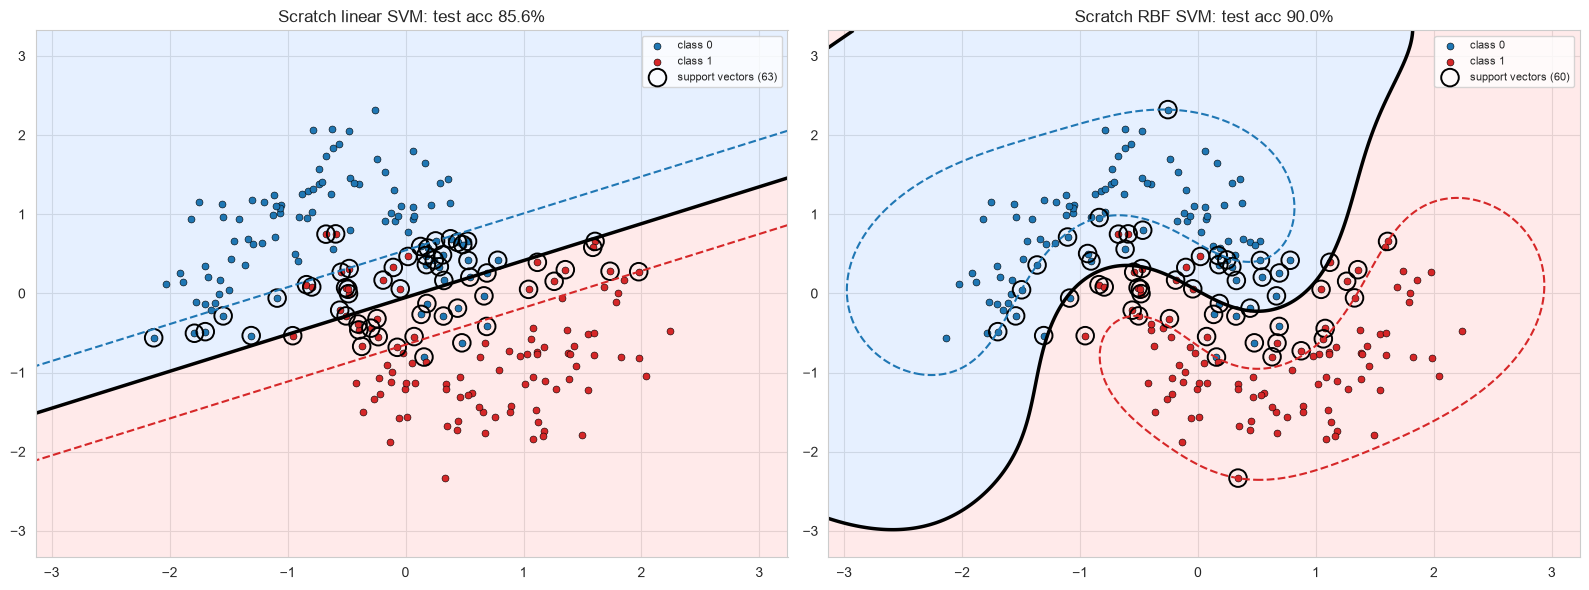

💡 Dashed lines are the margin (decision value ±1). The solid line is the boundary (value 0).
   Only the ringed points carry α > 0, and the decision function uses only those points.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_margins(axes[0], svm_lin_s, Xm_tr_s, ym_tr,
             f"Scratch linear SVM: test acc {svm_lin_s.score(Xm_te_s, ym_te):.1%}")
plot_margins(axes[1], svm_rbf_s, Xm_tr_s, ym_tr,
             f"Scratch RBF SVM: test acc {svm_rbf_s.score(Xm_te_s, ym_te):.1%}")
plt.tight_layout()
plt.show()

print("💡 Dashed lines are the margin (decision value ±1). The solid line is the boundary (value 0).")
print("   Only the ringed points carry α > 0, and the decision function uses only those points.")

### Solver Effort and Support Vectors vs C

Two things change as `C` grows: how many points become support vectors, and how hard the solver has to work. The twin reports its sweep count. A solver that stops at the sweep cap has not converged, and the twin does not hide that.

       C  sweeps  hit cap  support vectors  test acc
  0.1000      11    False              112    0.8889
  1.0000      18    False               60    0.9000
 10.0000      29    False               34    0.9778
100.0000     300     True               24    0.9444


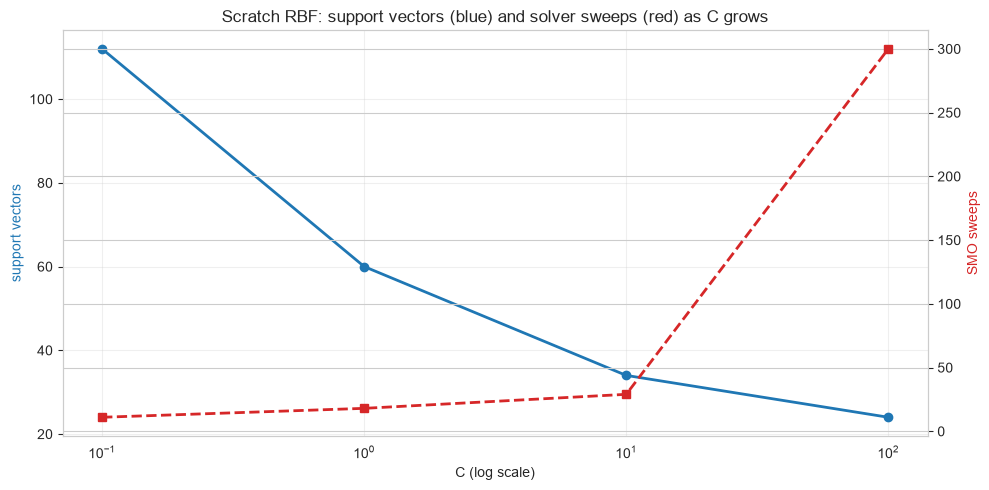


💡 `sweeps` is the solver's effort. If `hit cap` is True, the solver stopped at max_iter without
   converging. Raise max_iter or tol, or reduce n. The module documents this behavior on purpose.


In [10]:
MAX_SWEEPS = 300
rows_sweep = []
for C_val in [0.1, 1.0, 10.0, 100.0]:
    m_c = SVMClassifierScratch(kernel="rbf", C=C_val, gamma=GAMMA, max_iter=MAX_SWEEPS)
    m_c.fit(Xm_tr_s, ym_tr)
    rows_sweep.append({
        "C": C_val,
        "sweeps": m_c.n_iter_,
        "hit cap": m_c.n_iter_ >= MAX_SWEEPS,
        "support vectors": len(m_c.support_),
        "test acc": m_c.score(Xm_te_s, ym_te),
    })
sweep_df = pd.DataFrame(rows_sweep)
print(sweep_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.semilogx(sweep_df["C"], sweep_df["support vectors"], "o-", color="#1f77b4", lw=2)
ax1.set_xlabel("C (log scale)")
ax1.set_ylabel("support vectors", color="#1f77b4")
ax2 = ax1.twinx()
ax2.semilogx(sweep_df["C"], sweep_df["sweeps"], "s--", color="#d62728", lw=2)
ax2.set_ylabel("SMO sweeps", color="#d62728")
ax1.set_title("Scratch RBF: support vectors (blue) and solver sweeps (red) as C grows")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 `sweeps` is the solver's effort. If `hit cap` is True, the solver stopped at max_iter without")
print("   converging. Raise max_iter or tol, or reduce n. The module documents this behavior on purpose.")

### Reconstructing the Decision Function by Hand

The decision rule is literally $f(x) = \sum_{sv} \alpha_{sv}\, y_{sv}\, K(x_{sv}, x) + b$. Rebuilding it from the stored support vectors shows that nothing else from training is needed at prediction time.

In [11]:
K_test_s = rbf_kernel(Xm_te_s, svm_rbf_s.support_vectors_, gamma=GAMMA)   # shape (n_test, n_sv)
f_manual = K_test_s @ svm_rbf_s.dual_coef_ + svm_rbf_s.intercept_
f_api = svm_rbf_s.decision_function(Xm_te_s)
pred_from_sign = np.where(f_manual > 0, svm_rbf_s.classes_[1], svm_rbf_s.classes_[0])

print(f"Support vectors used: {len(svm_rbf_s.support_)} of {len(Xm_tr_s)} training rows")
print(f"Max |hand-built f(x) - decision_function(x)| = {np.max(np.abs(f_manual - f_api)):.2e}")
print(f"Hand-built sign matches predict(): {np.array_equal(pred_from_sign, svm_rbf_s.predict(Xm_te_s))}")
print("\n💡 Prediction = sign(sum over support vectors of α·y·K(x_sv, x) + b). Training rows that are not")
print("   support vectors never appear again.")

Support vectors used: 60 of 210 training rows
Max |hand-built f(x) - decision_function(x)| = 1.33e-15
Hand-built sign matches predict(): True

💡 Prediction = sign(sum over support vectors of α·y·K(x_sv, x) + b). Training rows that are not
   support vectors never appear again.


### How the Scratch Version Works (a guided tour)

Read `src/models/svm_models.py` alongside these facts:

**1. The Gram matrix is precomputed once per fit (`_gram`, called from `_solve_pair`).**
Every SMO step reads rows $K_{i,:}$ and $K_{j,:}$ many times, so the module computes the full $n \times n$ kernel matrix up front. That is $O(n^2)$ memory, which is why the twin targets few-hundred-row fits. libSVM caches kernel rows on demand instead.

**2. The KKT check decides which rows need work (`_smo_solve`).**
With error $E_i = f(x_i) - y_i$, row $i$ violates KKT at tolerance `tol` if either $y_i E_i < -\text{tol}$ while $\alpha_i < C$ (inside the margin and still allowed to grow), or $y_i E_i > \text{tol}$ while $\alpha_i > 0$ (outside the margin but still carrying weight).

**3. The second choice is a deterministic ladder.**
For a violating row $i$, the partner $j$ is the row with the largest $|E_i - E_j|$. If that pair is degenerate (equal-label pairs frozen at $\alpha = (0, 0)$, $\eta \ge 0$, or no movement), the next-largest gap is tried, and so on. Without this ladder a sweep can finish with zero steps while violations remain. The CS229 simplified SMO picks a random partner in that situation. The module replaces that randomness with the deterministic ladder.

**4. The pair update is closed form.**
Two alphas move along the line that keeps $\sum_i \alpha_i y_i$ fixed. The box constraints $0 \le \alpha \le C$ give bounds $[L, H]$ for the step. The unconstrained optimum is
$$\alpha_i^{\text{new}} = \alpha_i + \frac{y_i\,(E_i - E_j)}{\eta}, \qquad \eta = 2K_{ij} - K_{ii} - K_{jj} < 0,$$
which is then clipped to $[L, H]$.

**5. The bias uses the final, clipped alphas.**
$b_1$ and $b_2$ are computed from the updated alphas. The one that sits strictly inside its bounds sets $b$, so that $f(x_i) = y_i$ or $f(x_j) = y_j$. If both alphas sit on a bound, the module averages them. Using pre-clip deltas here is a classic SMO bug, and the module avoids it explicitly.

**6. Errors stay consistent incrementally.**
After each accepted step, the decision values of all rows are updated at once, $f \mathrel{+}= \Delta_i K_{i,:} + \Delta_j K_{j,:} + \Delta b$, and $E = f - y$ is recomputed. Stale-error bugs cannot creep in.

**7. Multiclass is one-vs-one with confidence-weighted voting.**
For $K$ classes the twin solves $K(K-1)/2$ binary problems, each on the rows of its two classes. A pair decision $d$ adds $+|d|$ to the class it favors and $-|d|$ to the other. Prediction takes the most-voted class, breaking ties by aggregated score. sklearn counts plain unit votes by default, so the two can disagree on multiclass ties (see §8).

**8. What the twin deliberately leaves out.** No shrinking, no kernel cache, no `predict_proba`, no `class_weight`, no SVR, no sigmoid kernel, no precomputed kernels. `max_iter` counts full passes over the data. On heavily overlapping data the optimizer can stop early without reaching full KKT convergence. That is a documented simplification, not a bug.

---

## 6. Implementation with Scikit-learn

scikit-learn's `SVC` wraps **libSVM** (Chang & Lin 2011), a mature SMO-style solver with second-order working-set selection, shrinking, and a kernel cache. `LinearSVC` wraps **liblinear** and is the right tool for large linear problems. A few API facts are worth pinning before the first fit:

- `predict_proba` is available only with `probability=True`. That runs an internal 5-fold Platt scaling step and makes fitting several times slower
- Without it, the model gives signed margin distances (`decision_function`), not probabilities
- Multiclass is one-vs-one inside `SVC` and one-vs-rest inside `LinearSVC`
- Scaling belongs inside a `Pipeline`, so the scaler only sees training data

In [12]:
svc_sk = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))])
svc_sk.fit(Xm_tr, ym_tr)
svc_fit = svc_sk.named_steps["svc"]
y_pred_sk = svc_sk.predict(Xm_te)
margin_sk = svc_sk.decision_function(Xm_te)

print("=" * 60)
print("SVM CLASSIFIER (SCIKIT-LEARN)")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(ym_te, y_pred_sk):.4f}")
print(f"  Precision: {precision_score(ym_te, y_pred_sk):.4f}")
print(f"  Recall:    {recall_score(ym_te, y_pred_sk):.4f}")
print(f"  F1-Score:  {f1_score(ym_te, y_pred_sk):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(ym_te, margin_sk):.4f}   (from decision values, no probabilities needed)")

print("\n📋 Classification Report:")
print(classification_report(ym_te, y_pred_sk, target_names=["Class 0", "Class 1"]))

print("🔍 Fitted attributes:")
print(f"  classes_          = {svc_fit.classes_}")
print(f"  n_support_        = {svc_fit.n_support_}   (per class)")
print(f"  support_vectors_  = {svc_fit.support_vectors_.shape}")
print(f"  n_iter_           = {svc_fit.n_iter_}   (solver iterations used)")
print(f"  intercept_        = {svc_fit.intercept_}")
print(f"  probability       = {svc_fit.probability}   (predict_proba raises unless this is True)")

SVM CLASSIFIER (SCIKIT-LEARN)
  Accuracy:  0.9000
  Precision: 0.8600
  Recall:    0.9556
  F1-Score:  0.9053
  ROC-AUC:   0.9896   (from decision values, no probabilities needed)

📋 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.84      0.89        45
     Class 1       0.86      0.96      0.91        45

    accuracy                           0.90        90
   macro avg       0.91      0.90      0.90        90
weighted avg       0.91      0.90      0.90        90

🔍 Fitted attributes:
  classes_          = [0 1]
  n_support_        = [30 29]   (per class)
  support_vectors_  = (59, 2)
  n_iter_           = [73]   (solver iterations used)
  intercept_        = [0.0237034]
  probability       = deprecated   (predict_proba raises unless this is True)


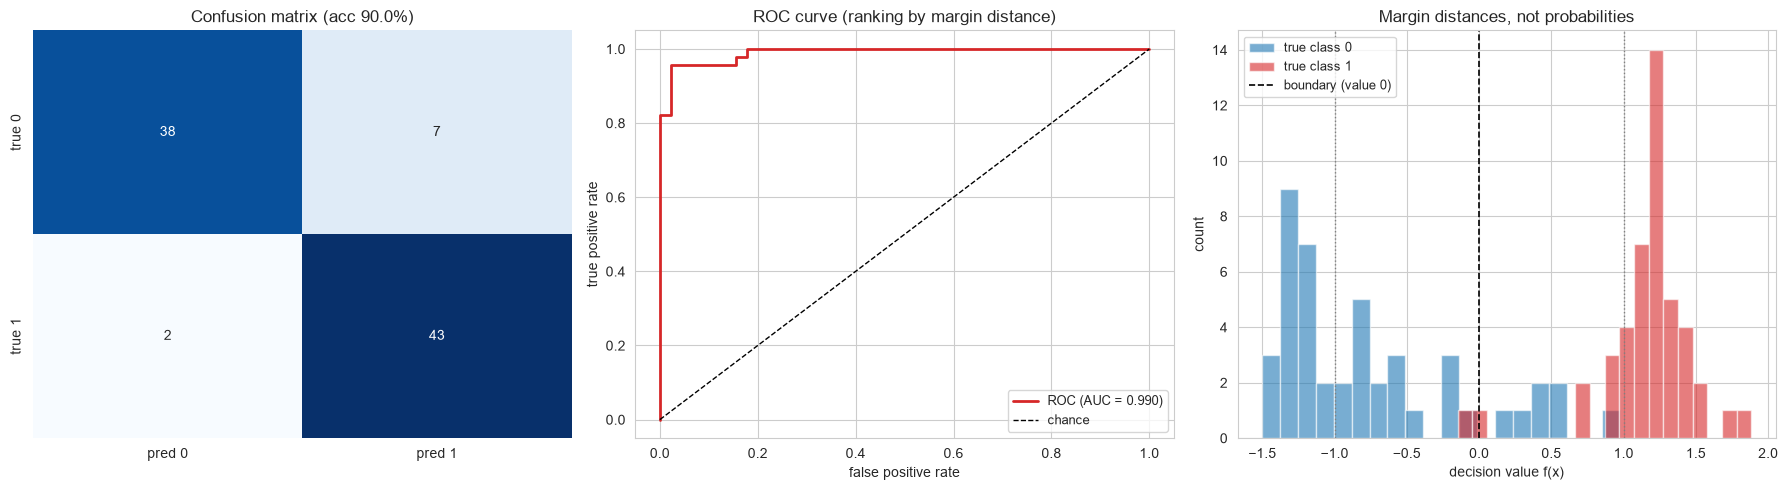

💡 The decision value is a signed distance to the boundary, in margin units.
   Values near ±1 sit on the margin, and values near 0 are the uncertain band.
   Turning it into a probability is a separate step (§10 Example 1 calibrates it).


In [13]:
cm_sk = confusion_matrix(ym_te, y_pred_sk)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(cm_sk, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
axes[0].set_title(f"Confusion matrix (acc {accuracy_score(ym_te, y_pred_sk):.1%})")

fpr_m, tpr_m, _ = roc_curve(ym_te, margin_sk)
axes[1].plot(fpr_m, tpr_m, color="#d62728", lw=2,
             label=f"ROC (AUC = {roc_auc_score(ym_te, margin_sk):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (ranking by margin distance)")
axes[1].legend(fontsize=9)

axes[2].hist(margin_sk[ym_te == 0], bins=20, alpha=0.6, color="#1f77b4", label="true class 0")
axes[2].hist(margin_sk[ym_te == 1], bins=20, alpha=0.6, color="#d62728", label="true class 1")
axes[2].axvline(0.0, color="black", ls="--", lw=1.2, label="boundary (value 0)")
axes[2].axvline(-1.0, color="gray", ls=":", lw=1)
axes[2].axvline(1.0, color="gray", ls=":", lw=1)
axes[2].set_xlabel("decision value f(x)")
axes[2].set_ylabel("count")
axes[2].set_title("Margin distances, not probabilities")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("💡 The decision value is a signed distance to the boundary, in margin units.")
print("   Values near ±1 sit on the margin, and values near 0 are the uncertain band.")
print("   Turning it into a probability is a separate step (§10 Example 1 calibrates it).")

### Kernel Comparison

The same scaled data through three kernels. Each panel uses the `plot_margins` helper on the scaled arrays, so the margin lines are drawn in the coordinates the model actually sees.

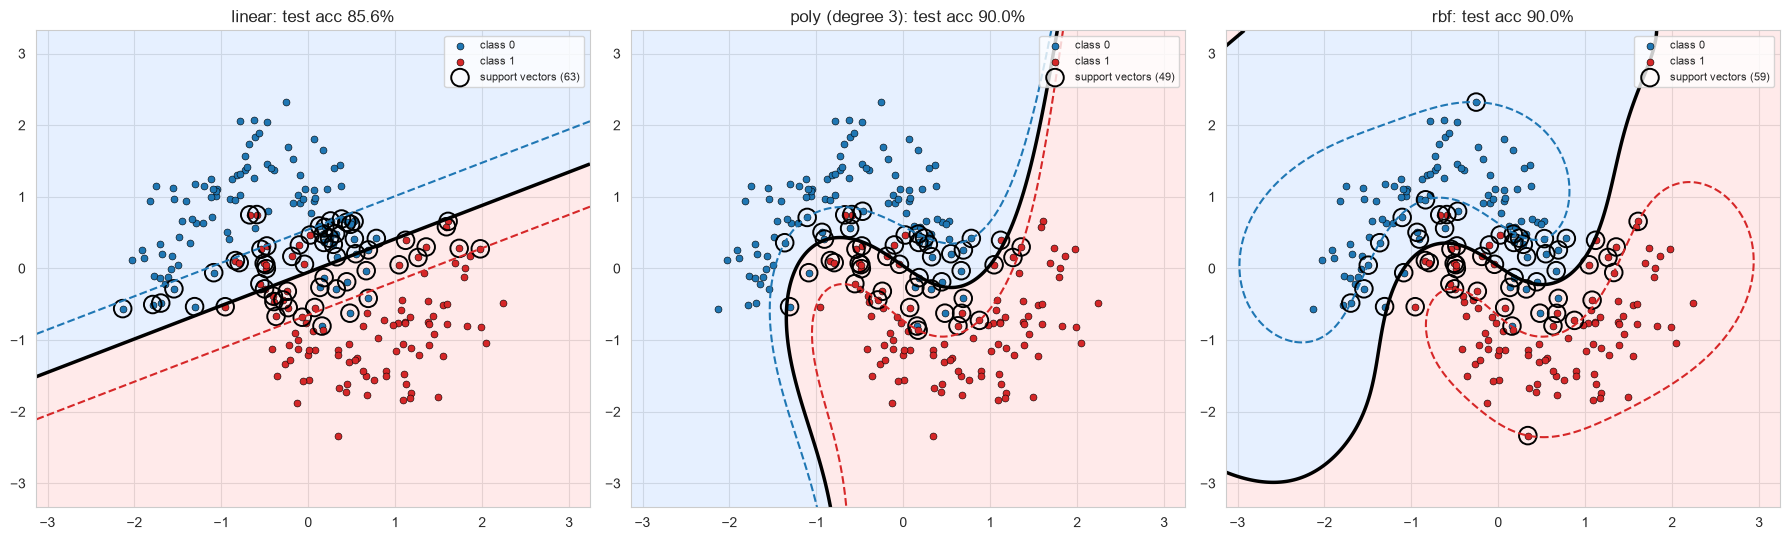

         kernel  test accuracy  support vectors  fit (s)
         linear         0.8556               63   0.0014
poly (degree 3)         0.9000               49   0.0014
            rbf         0.9000               59   0.0012

💡 The linear kernel draws a straight band. Poly bends it. RBF wraps the moons with the fewest
   assumptions about shape. The support-vector column shows how much each boundary had to memorize.


In [14]:
kernel_specs = [
    ("linear", dict(kernel="linear", C=1.0)),
    ("poly (degree 3)", dict(kernel="poly", degree=3, C=1.0, gamma="scale", coef0=1.0)),
    ("rbf", dict(kernel="rbf", C=1.0, gamma="scale")),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
rows_k = []
for ax, (name, params) in zip(axes, kernel_specs):
    svc_k = SVC(**params)
    t0 = time.perf_counter()
    svc_k.fit(Xm_tr_s, ym_tr)
    t_k = time.perf_counter() - t0
    acc_k = svc_k.score(Xm_te_s, ym_te)
    rows_k.append({"kernel": name, "test accuracy": acc_k,
                   "support vectors": len(svc_k.support_), "fit (s)": t_k})
    plot_margins(ax, svc_k, Xm_tr_s, ym_tr, f"{name}: test acc {acc_k:.1%}")
plt.tight_layout()
plt.show()

kernel_df = pd.DataFrame(rows_k)
print(kernel_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n💡 The linear kernel draws a straight band. Poly bends it. RBF wraps the moons with the fewest")
print("   assumptions about shape. The support-vector column shows how much each boundary had to memorize.")

### Dual Engine: Scratch vs Scikit-learn on the Same Data

Both engines get the same scaled arrays, the same `C`, and the same explicit `GAMMA`. They should land on nearly the same margin function. They will not match exactly, and the reason is worth knowing: both solvers stop when KKT violations fall below a tolerance, but they use different working-set rules. So the dual coefficients and the bias differ slightly even when the decision values agree closely.

In [15]:
t0 = time.perf_counter()
scratch_rbf = SVMClassifierScratch(kernel="rbf", C=1.0, gamma=GAMMA, max_iter=1000).fit(Xm_tr_s, ym_tr)
t_scr = time.perf_counter() - t0

t0 = time.perf_counter()
sk_rbf = SVC(kernel="rbf", C=1.0, gamma=GAMMA).fit(Xm_tr_s, ym_tr)
t_skl = time.perf_counter() - t0

pred_scr = scratch_rbf.predict(Xm_te_s)
pred_skl = sk_rbf.predict(Xm_te_s)
dec_scr = scratch_rbf.decision_function(Xm_te_s)
dec_skl = sk_rbf.decision_function(Xm_te_s)

print("=" * 60)
print("DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (RBF, same data, same gamma)")
print("=" * 60)
print(f"| {'Metric':<28s} | {'Scratch':>12s} | {'Scikit-learn':>12s} |")
print(f"|{'-' * 30}|{'-' * 14}|{'-' * 14}|")
print(f"| {'test accuracy':<28s} | {accuracy_score(ym_te, pred_scr):12.4f} | {accuracy_score(ym_te, pred_skl):12.4f} |")
print(f"| {'support vectors':<28s} | {len(scratch_rbf.support_):12d} | {len(sk_rbf.support_):12d} |")
print(f"| {'fit time (s)':<28s} | {t_scr:12.3f} | {t_skl:12.3f} |")
print(f"\nPrediction agreement on test rows: {np.mean(pred_scr == pred_skl):.1%}")
print(f"Max |decision difference|:         {np.max(np.abs(dec_scr - dec_skl)):.4f}")
print(f"Correlation of decision values:    {np.corrcoef(dec_scr, dec_skl)[0, 1]:.6f}")
print("\n💡 Both engines minimize the same convex dual with the same kernel width. Agreement in predictions and")
print("   margin values is what this check is for. Differences in α and b reflect the solvers, not the math.")

DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (RBF, same data, same gamma)
| Metric                       |      Scratch | Scikit-learn |
|------------------------------|--------------|--------------|
| test accuracy                |       0.9000 |       0.9000 |
| support vectors              |           60 |           59 |
| fit time (s)                 |        0.073 |        0.001 |

Prediction agreement on test rows: 100.0%
Max |decision difference|:         0.0011
Correlation of decision values:    1.000000

💡 Both engines minimize the same convex dual with the same kernel width. Agreement in predictions and
   margin values is what this check is for. Differences in α and b reflect the solvers, not the math.


### Regression with Scikit-learn: SVR

The same kernel machinery solves regression with an **ε-insensitive tube**. The loss is

$$L_\varepsilon\big(y, f(x)\big) = \max\big(0,\; |y - f(x)| - \varepsilon\big)$$

A prediction within $\pm\varepsilon$ of the target costs nothing. Only points on or outside the tube become support vectors, and `C` controls how hard those violations are penalized. The twin is classifier-only, so this section uses scikit-learn alone.

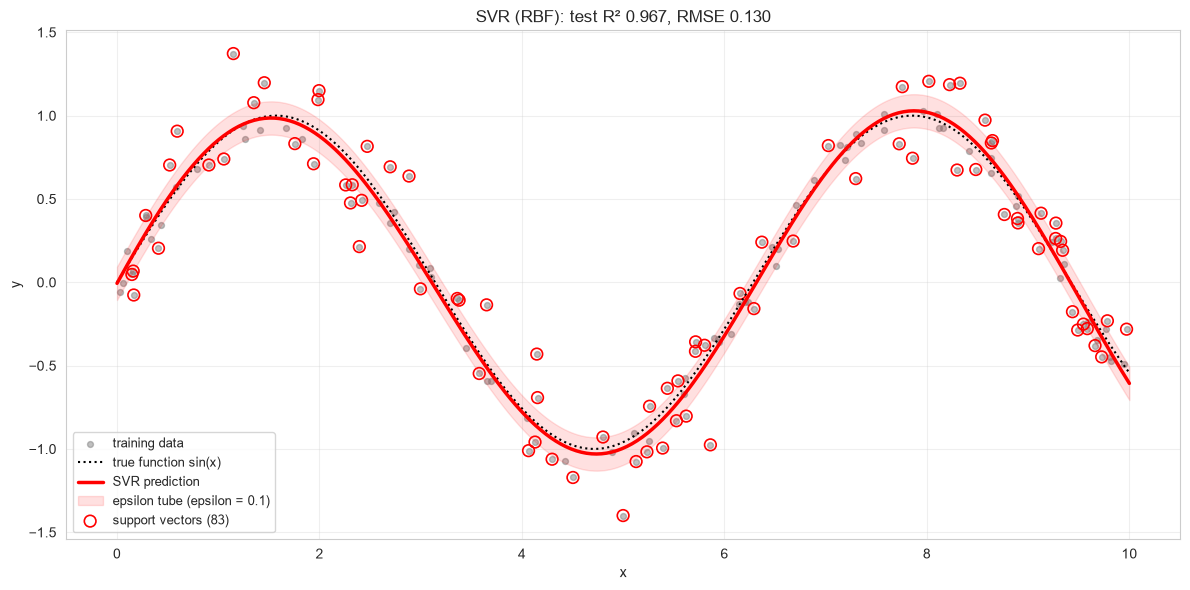

Test R²: 0.9668 | Test RMSE: 0.1295
Support vectors: 83 of 150 training points

💡 Points inside the ±epsilon tube cost nothing and never become support vectors.
   Points on or outside the tube are the support vectors. C sets how hard they are penalized.


In [16]:
rng_r = np.random.default_rng(0)
X_sine = np.sort(rng_r.uniform(0.0, 10.0, 200)).reshape(-1, 1)
y_sine = np.sin(X_sine).ravel() + rng_r.normal(0.0, 0.15, 200)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_sine, y_sine, test_size=0.25, random_state=42)

svr_pipe = Pipeline([("sc", StandardScaler()),
                     ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"))])
svr_pipe.fit(Xs_tr, ys_tr)
svr_model = svr_pipe.named_steps["svr"]

pred_sine_te = svr_pipe.predict(Xs_te)
r2_svr = r2_score(ys_te, pred_sine_te)
rmse_svr = np.sqrt(mean_squared_error(ys_te, pred_sine_te))

grid_x = np.linspace(0.0, 10.0, 400).reshape(-1, 1)
grid_pred = svr_pipe.predict(grid_x)
sv_idx = svr_model.support_

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(Xs_tr[:, 0], ys_tr, s=18, alpha=0.5, color="gray", label="training data")
ax.plot(grid_x[:, 0], np.sin(grid_x[:, 0]), "k:", lw=1.5, label="true function sin(x)")
ax.plot(grid_x[:, 0], grid_pred, "r-", lw=2.5, label="SVR prediction")
ax.fill_between(grid_x[:, 0], grid_pred - 0.1, grid_pred + 0.1, color="red", alpha=0.12,
                label="epsilon tube (epsilon = 0.1)")
ax.scatter(Xs_tr[sv_idx, 0], ys_tr[sv_idx], s=70, facecolors="none", edgecolors="red",
           linewidths=1.2, label=f"support vectors ({len(sv_idx)})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"SVR (RBF): test R² {r2_svr:.3f}, RMSE {rmse_svr:.3f}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Test R²: {r2_svr:.4f} | Test RMSE: {rmse_svr:.4f}")
print(f"Support vectors: {len(sv_idx)} of {len(Xs_tr)} training points")
print("\n💡 Points inside the ±epsilon tube cost nothing and never become support vectors.")
print("   Points on or outside the tube are the support vectors. C sets how hard they are penalized.")

---

## 7. Hyperparameter Tuning

For an RBF SVM the levers that matter are **C** (the violation penalty), **γ** (the kernel width), and the **kernel** itself. Imbalanced problems add `class_weight`, and the decision threshold is a free lever. Three rules govern tuning:

1. Search on **log-scale grids**. Both C and γ act multiplicatively
2. Tune with **stratified cross-validation on training data only**
3. Keep the **test set** for the final report, not for choosing anything

The tuning data below is a noisier moons set, so the boundary has something to overfit.

✨ Best parameters: C = 1000, gamma = 0.1
✨ Best CV accuracy: 0.9333
📊 Held-out test accuracy with the best model: 0.9600


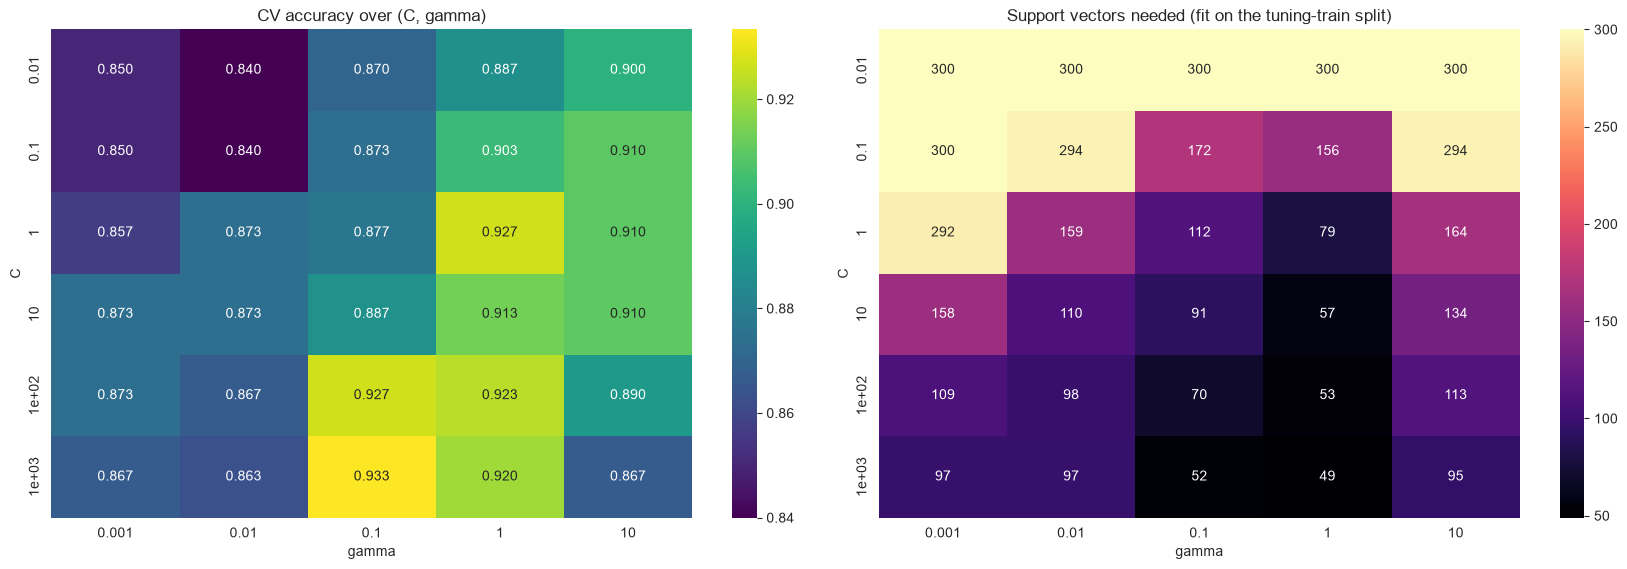


💡 Read the two panels together. A setting that buys a little CV accuracy with many more support
   vectors pays for it in memory and in prediction time.


In [17]:
X_tune, y_tune = make_moons(n_samples=400, noise=0.25, random_state=3)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_tune, y_tune, test_size=0.25,
                                              stratify=y_tune, random_state=42)

tune_pipe = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf"))])
C_grid = np.logspace(-2, 3, 6)          # 0.01 ... 1000
gamma_grid = np.logspace(-3, 1, 5)      # 0.001 ... 10
grid_tune = GridSearchCV(
    tune_pipe,
    {"svc__C": C_grid, "svc__gamma": gamma_grid},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
)
grid_tune.fit(Xt_tr, yt_tr)

best_C = grid_tune.best_params_["svc__C"]
best_gamma = grid_tune.best_params_["svc__gamma"]
print(f"✨ Best parameters: C = {best_C:.4g}, gamma = {best_gamma:.4g}")
print(f"✨ Best CV accuracy: {grid_tune.best_score_:.4f}")
print(f"📊 Held-out test accuracy with the best model: {grid_tune.score(Xt_te, yt_te):.4f}")

cv_table = pd.DataFrame(grid_tune.cv_results_).pivot_table(
    values="mean_test_score", index="param_svc__C", columns="param_svc__gamma")

sc_t = StandardScaler().fit(Xt_tr)
Xt_tr_s = sc_t.transform(Xt_tr)
n_sv_mat = np.zeros((len(C_grid), len(gamma_grid)), dtype=int)
for i_c, c_val in enumerate(C_grid):
    for j_g, g_val in enumerate(gamma_grid):
        n_sv_mat[i_c, j_g] = len(SVC(kernel="rbf", C=c_val, gamma=g_val).fit(Xt_tr_s, yt_tr).support_)
n_sv_table = pd.DataFrame(n_sv_mat, index=C_grid, columns=gamma_grid)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.8))
sns.heatmap(cv_table, annot=True, fmt=".3f", cmap="viridis", ax=axes[0],
            yticklabels=[f"{c:.2g}" for c in cv_table.index],
            xticklabels=[f"{g:.2g}" for g in cv_table.columns])
axes[0].set_title("CV accuracy over (C, gamma)")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("C")
sns.heatmap(n_sv_table, annot=True, fmt="d", cmap="magma", ax=axes[1],
            yticklabels=[f"{c:.2g}" for c in n_sv_table.index],
            xticklabels=[f"{g:.2g}" for g in n_sv_table.columns])
axes[1].set_title("Support vectors needed (fit on the tuning-train split)")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("C")
plt.tight_layout()
plt.show()

print("\n💡 Read the two panels together. A setting that buys a little CV accuracy with many more support")
print("   vectors pays for it in memory and in prediction time.")

### The C Sweep: Training Keeps Climbing

Hold γ at the tuned value and sweep `C` over a wide log range. Training accuracy climbs as `C` grows, because the boundary is allowed to fit more individual points. The train-test gap is the warning sign. Choose `C` from cross-validation, as above. Do not choose it from this plot.

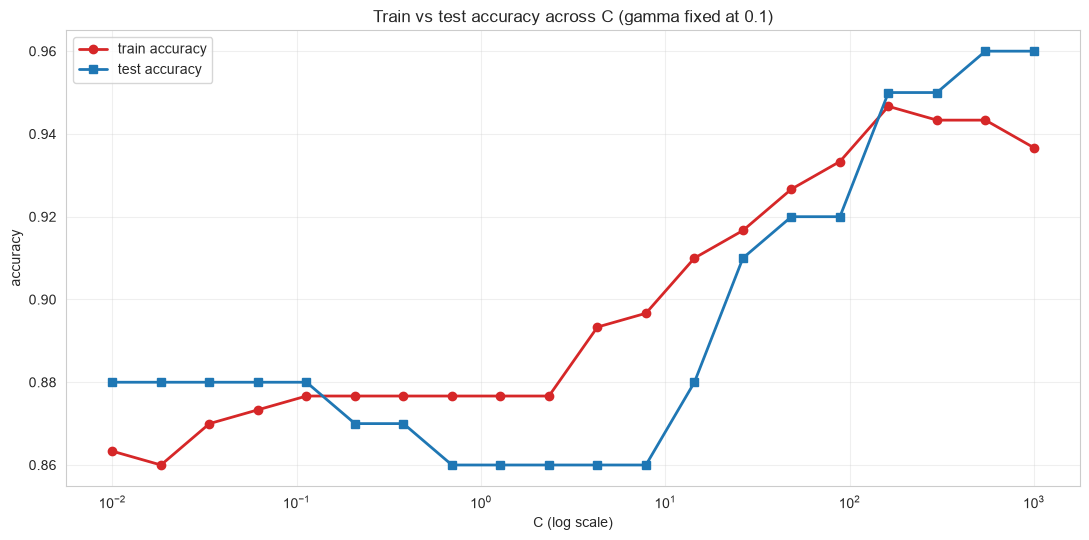

At the largest C: train 0.9367 vs test 0.9600 (gap -0.0233)

💡 Large C asks the boundary to fit every training point. Watch the train-test gap, not the training score.


In [18]:
C_range = np.logspace(-2, 3, 20)
train_acc_c, test_acc_c = [], []
for c_val in C_range:
    m_t = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=c_val, gamma=best_gamma))])
    m_t.fit(Xt_tr, yt_tr)
    train_acc_c.append(m_t.score(Xt_tr, yt_tr))
    test_acc_c.append(m_t.score(Xt_te, yt_te))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.semilogx(C_range, train_acc_c, "o-", color="#d62728", lw=2, label="train accuracy")
ax.semilogx(C_range, test_acc_c, "s-", color="#1f77b4", lw=2, label="test accuracy")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("accuracy")
ax.set_title(f"Train vs test accuracy across C (gamma fixed at {best_gamma:.3g})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At the largest C: train {train_acc_c[-1]:.4f} vs test {test_acc_c[-1]:.4f} "
      f"(gap {train_acc_c[-1] - test_acc_c[-1]:+.4f})")
print("\n💡 Large C asks the boundary to fit every training point. Watch the train-test gap, not the training score.")

### Gamma: Smooth Bands vs Islands

The same kernel at three widths on the tuning-train split. The picture is the lesson: the kernel width decides how local each support vector's influence is.

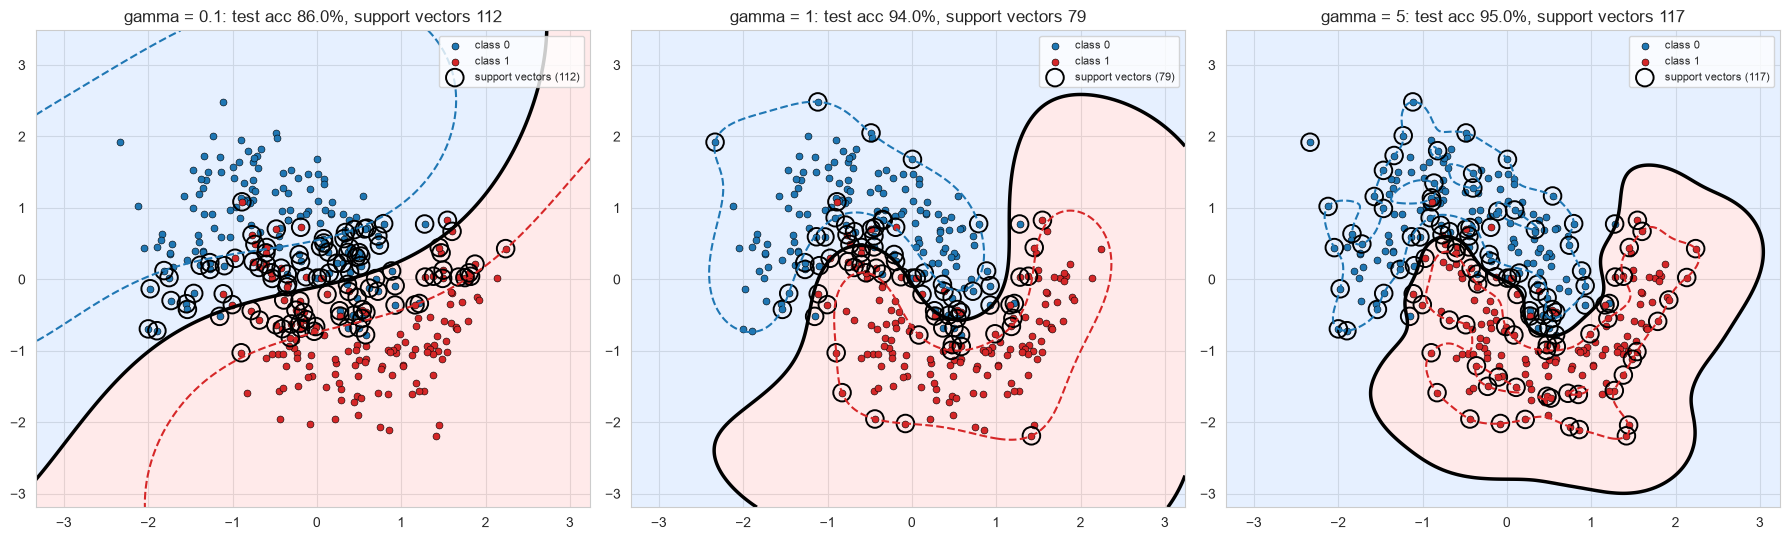

💡 Small gamma gives broad, smooth bands. Large gamma lets each support vector carve its own island.
   That pattern is memorization. The test accuracies above show whether it paid off on this data.


In [19]:
gamma_demo = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, g_val in zip(axes, gamma_demo):
    m_g = SVC(kernel="rbf", C=1.0, gamma=g_val).fit(Xt_tr_s, yt_tr)
    acc_g = m_g.score(sc_t.transform(Xt_te), yt_te)
    plot_margins(ax, m_g, Xt_tr_s, yt_tr,
                 f"gamma = {g_val:g}: test acc {acc_g:.1%}, support vectors {len(m_g.support_)}")
plt.tight_layout()
plt.show()

print("💡 Small gamma gives broad, smooth bands. Large gamma lets each support vector carve its own island.")
print("   That pattern is memorization. The test accuracies above show whether it paid off on this data.")

### Threshold: The Free Lever

The decision threshold on $f(x)$ is a second knob that needs no retraining. It trades precision against recall, and it should be chosen from **out-of-fold training scores**, never from the test set. The procedure below picks the F1-optimal threshold from cross-validated decision values on the training split, then reports the test set once.

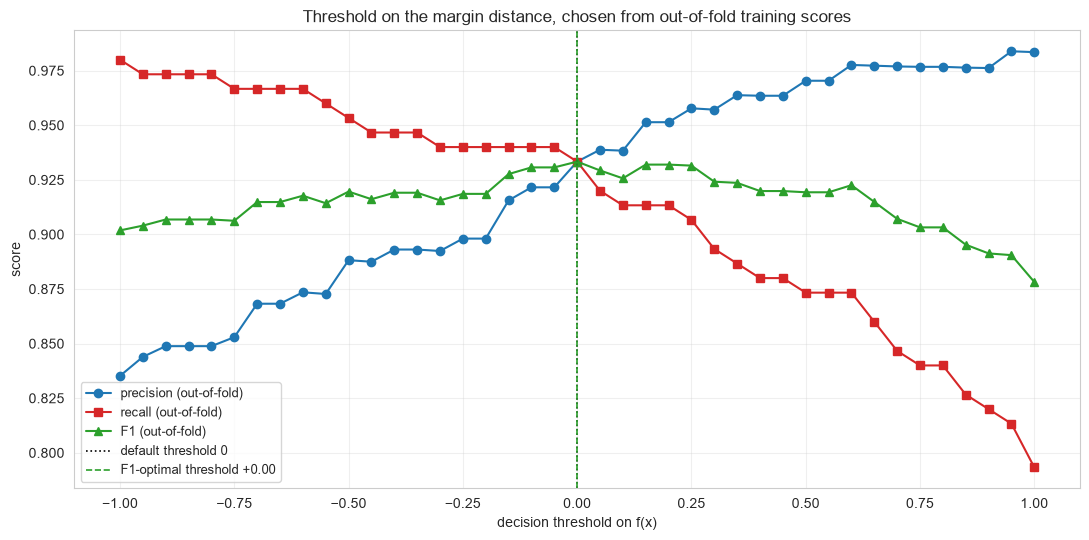

F1-optimal threshold (out-of-fold, training split only): +0.00
Test set, default threshold 0:    accuracy 0.9600, F1 0.9592
Test set, tuned threshold +0.00: accuracy 0.9600, F1 0.9592

💡 Moving the threshold changes the decision, not the model. Choose it on out-of-fold scores, then check
   it once on the test set. Tuning it on the test set is the same leak as tuning C on the test set.


In [20]:
from sklearn.model_selection import cross_val_predict

oof_dec = cross_val_predict(
    Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=best_C, gamma=best_gamma))]),
    Xt_tr, yt_tr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method="decision_function",
)
thresholds_t = np.linspace(-1.0, 1.0, 41)
prec_oof, rec_oof, f1_oof = [], [], []
for t_val in thresholds_t:
    pred_t = (oof_dec >= t_val).astype(int)
    prec_oof.append(precision_score(yt_tr, pred_t, zero_division=0))
    rec_oof.append(recall_score(yt_tr, pred_t, zero_division=0))
    f1_oof.append(f1_score(yt_tr, pred_t, zero_division=0))
best_t = float(thresholds_t[int(np.argmax(f1_oof))])

best_model_t = SVC(kernel="rbf", C=best_C, gamma=best_gamma).fit(Xt_tr_s, yt_tr)
dec_te = best_model_t.decision_function(sc_t.transform(Xt_te))
pred_default = (dec_te >= 0.0).astype(int)
pred_tuned = (dec_te >= best_t).astype(int)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(thresholds_t, prec_oof, "o-", color="#1f77b4", label="precision (out-of-fold)")
ax.plot(thresholds_t, rec_oof, "s-", color="#d62728", label="recall (out-of-fold)")
ax.plot(thresholds_t, f1_oof, "^-", color="#2ca02c", label="F1 (out-of-fold)")
ax.axvline(0.0, color="black", ls=":", lw=1.2, label="default threshold 0")
ax.axvline(best_t, color="#2ca02c", ls="--", lw=1.2, label=f"F1-optimal threshold {best_t:+.2f}")
ax.set_xlabel("decision threshold on f(x)")
ax.set_ylabel("score")
ax.set_title("Threshold on the margin distance, chosen from out-of-fold training scores")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"F1-optimal threshold (out-of-fold, training split only): {best_t:+.2f}")
print(f"Test set, default threshold 0:    accuracy {accuracy_score(yt_te, pred_default):.4f}, "
      f"F1 {f1_score(yt_te, pred_default):.4f}")
print(f"Test set, tuned threshold {best_t:+.2f}: accuracy {accuracy_score(yt_te, pred_tuned):.4f}, "
      f"F1 {f1_score(yt_te, pred_tuned):.4f}")
print("\n💡 Moving the threshold changes the decision, not the model. Choose it on out-of-fold scores, then check")
print("   it once on the test set. Tuning it on the test set is the same leak as tuning C on the test set.")

---

## 8. Complete Hyperparameter Reference

### SVC Parameters (scikit-learn 1.9)

#### `C` (float, default=1.0) **[THE HYPERPARAMETER]**
- **Description**: penalty per unit of margin violation (slack). Inverse strength of regularization
- **Effect**:
  - **Small C**: wide margin, more tolerated training errors, smoother boundary
  - **Large C**: narrow margin, fits more training points, higher complexity
- **Tuning strategy**: log grid from about 0.01 to 1000 with stratified CV (§7)
- **Example**: `SVC(C=10)`

#### `kernel` (str, default='rbf')
- **Options**: `'linear'`, `'poly'`, `'rbf'`, `'sigmoid'`, a callable, or `'precomputed'` (pass your own Gram matrix)
- **Effect**: the shape of the boundary
- **Tuning strategy**: start with `'linear'` as a baseline, then `'rbf'`. Polynomial kernels rarely beat RBF on continuous features
- **Example**: `SVC(kernel='linear')`

#### `degree` (int, default=3)
- **Description**: polynomial degree when `kernel='poly'`. Ignored by the other kernels
- **Example**: `SVC(kernel='poly', degree=2)`

#### `gamma` (str or float, default='scale')
- **Description**: RBF, polynomial, and sigmoid width
  - `'scale'` = `1 / (n_features × X.var())`, the default and the right starting point
  - `'auto'` = `1 / n_features`
  - a positive float is used directly
- **Effect**: large gamma gives islands and memorization, small gamma gives smooth bands
- **Tuning strategy**: log grid, for example 0.001 to 10 on standardized features
- **Example**: `SVC(gamma=0.5)`

#### `coef0` (float, default=0.0)
- **Description**: independent term in the polynomial and sigmoid kernels
- **Example**: `SVC(kernel='poly', coef0=1.0)`

#### `tol` (float, default=1e-3)
- **Description**: KKT tolerance that ends the solver. Looser is faster and less precise
- **Example**: `SVC(tol=1e-4)` for tighter convergence

#### `max_iter` (int, default=-1)
- **Description**: hard cap on solver iterations. `-1` means no limit
- **Note**: if the cap is hit, sklearn warns that the solver terminated early. Raise the cap, scale the features, or reduce n

#### `shrinking` (bool, default=True)
- **Description**: a heuristic that drops variables likely to stay at their bounds. Usually speeds training. Rarely needs changing

#### `probability` (bool, default=False)
- **Description**: enables `predict_proba` through internal 5-fold Platt scaling
- **Cost**: several times slower to fit. Without it, `predict_proba` raises
- **Alternative**: `CalibratedClassifierCV` (§10 Example 1), which gives you control over the calibration folds

#### `cache_size` (float, default=200)
- **Description**: kernel cache in MB. A larger cache speeds up training on big n at the cost of memory

#### `class_weight` (dict or `'balanced'`, default=None)
- **Description**: scales C per class. `'balanced'` weights classes inversely to their frequency
- **Example**: `SVC(class_weight='balanced')`

#### `decision_function_shape` (str, default='ovr')
- **Description**: for multiclass, `'ovr'` reports aggregated per-class scores with shape `(n_samples, n_classes)`. `'ovo'` reports the raw pairwise decisions
- **Note**: predictions still come from one-vs-one voting

#### `break_ties` (bool, default=False)
- **Description**: with `decision_function_shape='ovr'`, breaks ties among predicted classes using the decision values. Slower

#### `random_state` (int, default=None)
- **Description**: used only for the internal cross-validation shuffling when `probability=True`. Ignored otherwise

#### `verbose` (bool, default=False)
- **Description**: solver logging from libSVM

### SVR Extras (regression)

- **`epsilon`** (float, default=0.1): half-width of the tube. Errors inside ±ε cost nothing
- `C`, `kernel`, and `gamma` mean the same as in `SVC`
- **Example**: `SVR(kernel='rbf', C=10, epsilon=0.1)`

### LinearSVC (liblinear)

- **`C`**, **`loss`** (`'squared_hinge'` default, or `'hinge'`), **`penalty`** (`'l2'` default; `'l1'` needs a compatible loss and dual setting, see the API docs), **`class_weight`**, **`max_iter`** (default 1000), **`tol`**, **`random_state`** (shuffling for the dual solver)
- **Multiclass**: one-vs-rest. No kernels, and it scales far better than `SVC` in n
- **Example**: `LinearSVC(C=1.0, max_iter=5000)`

### Scratch Twin Coverage

| scikit-learn `SVC` parameter | Scratch twin | Notes |
|---|---|---|
| `C` | ✅ | same meaning |
| `kernel` | ✅ `linear`, `poly`, `rbf` | no `sigmoid`, no callable, no `precomputed` |
| `degree`, `coef0` | ✅ | same meaning |
| `gamma` | ✅ `'scale'`, `'auto'`, float | `'scale'` resolved from raw training X |
| `tol` | ✅ | KKT tolerance, default 1e-3 |
| `max_iter` | ✅ | counts full passes over the data, default 1000, not -1 |
| `shrinking`, `cache_size` | ❌ | full Gram matrix instead of a cache |
| `probability` | ❌ | no `predict_proba` |
| `class_weight` | ❌ | not implemented |
| `decision_function_shape`, `break_ties` | ❌ | multiclass always uses aggregated one-vs-one scores |
| `random_state` | ✅ accepted | unused, because the training path is deterministic |
| SVR | ❌ | classifier-only by design |

### Parameter Combination Recipes

#### Baseline (always start here):
```python
Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="linear", C=1.0))])
```

#### Default non-linear model:
```python
Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))])
```

#### Imbalanced classes:
```python
SVC(kernel="rbf", class_weight="balanced")
```

#### Large n, linear problem:
```python
LinearSVC(C=1.0, max_iter=5000)        # or SGDClassifier(loss="hinge") for streaming
```

#### Large n, non-linear problem (approximate the kernel first):
```python
from sklearn.kernel_approximation import Nystroem
Pipeline([("sc", StandardScaler()),
          ("nys", Nystroem(kernel="rbf", gamma=0.5, n_components=500, random_state=42)),
          ("clf", LinearSVC(C=1.0, max_iter=5000))])
```

#### Calibrated probabilities:
```python
CalibratedClassifierCV(Pipeline([("sc", StandardScaler()), ("svc", SVC())]), method="sigmoid", cv=5)
```

#### Regression:
```python
SVR(kernel="rbf", C=10.0, epsilon=0.1)
```

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Scale Features Inside a Pipeline**
Distances drive the kernel, so an unscaled column with a large range becomes the boundary. Scaling inside the pipeline keeps the scaler's statistics on training folds only.
```python
from sklearn.pipeline import Pipeline
pipe = Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf"))])
pipe.fit(X_train, y_train)      # no leakage inside cross-validation
```

---

#### 2. **Search C and γ on Log-scale Grids**
Both act multiplicatively. A linear grid wastes resolution at the extremes.
```python
param_grid = {"svc__C": np.logspace(-2, 3, 6), "svc__gamma": np.logspace(-3, 1, 5)}
```

---

#### 3. **Establish a Linear Baseline First**
A linear SVM is fast and tells you whether the problem is linear. If linear is close to RBF, the simpler model is usually the better choice.

---

#### 4. **Pick Metrics by Error Cost, Not Habit**
Accuracy hides rare-class failures. Report per-class precision and recall, and use ROC-AUC for ranking quality.
```python
classification_report(y_test, y_pred, target_names=[...])
roc_auc_score(y_test, pipe.decision_function(X_test))   # works without predict_proba
```

---

#### 5. **The Decision Threshold Is Free**
The default cut-off at 0 is a choice, not a law. Choose a threshold on out-of-fold decision values (§7), never on the test set.

---

#### 6. **Scale to Big Data Honestly**
Use `LinearSVC` or `SGDClassifier(loss="hinge")` for linear problems. Use a Nyström approximation followed by `LinearSVC` for non-linear problems at larger n. Exact RBF SVMs are the wrong tool at very large n.

---

#### 7. **Calibrate Before You Price a Decision on the Margin**
`CalibratedClassifierCV(method="sigmoid")` fits a Platt sigmoid with cross-validation. Sigmoid calibration is the sensible default for small and medium datasets. Isotonic calibration needs more rows.

---

#### 8. **Treat the Solver's Output as Health Checks**
Compare `n_iter_` with `max_iter`. Inspect the support-vector fraction after each fit: nearly every row being a support vector usually signals unscaled features or an extreme C or γ.

---

### ❌ Common Mistakes

#### 1. **Forgetting to Scale**
```python
# BAD:  SVC(kernel="rbf").fit(X_raw, y)        # one wide-range column dominates the distances
# GOOD: Pipeline([("sc", StandardScaler()), ("svc", SVC())]).fit(X_raw, y)
```

---

#### 2. **Huge γ or Huge C Memorizing the Training Set**
Training accuracy near 1.0 with weak test accuracy is the signature. Walk both parameters back on the log grid and let CV decide.

---

#### 3. **Reading the Decision Value as a Probability**
`decision_function` is a signed distance in margin units. A value of 0.4 is not a 40% chance. Calibrate first (§10).

---

#### 4. **Tuning on the Test Set**
Tuning C, gamma, or the threshold on the test set leaks the test set into the model. Keep the test set for one final report.

---

#### 5. **Using an RBF SVM on Very Large n**
Training cost and the kernel matrix grow super-linearly. Switch to `LinearSVC`, SGD, or an approximate kernel.

---

#### 6. **Linear Kernel on Curved Classes**
Accuracy stuck near a ceiling while RBF works is the diagnostic. Check the linear-versus-RBF gap under CV before blaming the data.

---

#### 7. **Calling `predict_proba` Without `probability=True`**
scikit-learn raises an `AttributeError`. Either set `probability=True` (slower) or calibrate with `CalibratedClassifierCV`.

---

#### 8. **Trusting Accuracy on Imbalanced Data**
A model that predicts the majority class everywhere can look excellent on accuracy. Use `class_weight='balanced'`, a threshold tuned on out-of-fold scores, and per-class metrics.

---

### Debugging Recipes

#### Training Is Painfully Slow?
1. Check n. An RBF SVM above tens of thousands of rows will be slow
2. Standardize the features, since badly scaled problems converge more slowly
3. For linear problems, switch to `LinearSVC` or `SGDClassifier`. For non-linear problems, use a Nyström approximation before `LinearSVC`

#### Accuracy Poor on Both Train and Test?
1. Underfitting. Increase `C` and `gamma` on the log grid
2. Check the kernel: a linear kernel on curved classes will not improve on its own
3. Check scaling; an unscaled feature can hide the signal

#### Train Accuracy High, Test Accuracy Low?
1. Overfitting. Reduce `C` and `gamma`
2. Recheck the CV split: stratified, shuffled, with a fixed seed
3. Look at the support-vector fraction. A very large share suggests memorization

#### "Solver Terminated Early" or LinearSVC "Failed to Converge"?
1. Scale the features first. This is the most common cause
2. Raise `max_iter` (LinearSVC default 1000)
3. Only then loosen `tol`, and do it consciously

#### Every Training Point Is a Support Vector?
1. Check scaling
2. Check whether C is very large relative to the class overlap
3. Check whether γ is very small, which makes the kernel almost constant

#### The Scratch Twin Is Slow or Hits `max_iter`?
1. The twin builds an $n \times n$ kernel matrix and runs Python loops. Keep demos to a few hundred rows
2. Compare `n_iter_` with `max_iter`. A capped run has not converged
3. Use scikit-learn's `SVC` for anything larger; the twin is for understanding the solver

---

## 10. Real-world Examples

Two examples chosen as a **pair of contrasts**:

- **Example 1: Breast Cancer Diagnosis (binary, medical).** The decision is a clinical one, and the important errors are the missed malignant tumors. The workflow is a scaled pipeline, CV tuning, per-class reporting, and calibration so the margin can be read as a risk score.
- **Example 2: Handwritten Digits (10 classes, image features).** The structure is multiclass. The workflow is one-vs-one under the hood: a single scaled RBF pipeline, per-class reporting, confusion analysis, and a look at the misclassified images.

Both datasets are bundled with scikit-learn, so no download is needed. Both run on scikit-learn at full size. The scratch twin is sized for a few hundred rows, so it is not used here.

### Example 1: Breast Cancer Diagnosis (Binary)

The Wisconsin Breast Cancer dataset has 569 tumors described by 30 numeric features. The label is malignant (0) or benign (1). This notebook keeps the sklearn convention of benign as the positive class, so the summary metrics describe benign. The per-class report and the miss counts are the clinically relevant numbers.

In [21]:
bc2 = load_breast_cancer()
Xbc, ybc = bc2.data, bc2.target                      # 0 = malignant, 1 = benign
Xbc_tr, Xbc_te, ybc_tr, ybc_te = train_test_split(Xbc, ybc, test_size=0.25,
                                                  stratify=ybc, random_state=42)

print("=" * 60)
print("REAL-WORLD EXAMPLE: BREAST CANCER (SVM, SCALED PIPELINE)")
print("=" * 60)
print(f"\n📊 {Xbc.shape[0]} tumors × {Xbc.shape[1]} features")
print(f"   malignant (0): {np.sum(ybc == 0)}   benign (1): {np.sum(ybc == 1)}")
print(f"   Train/test: {len(ybc_tr)} / {len(ybc_te)} (stratified)")

bc_grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf"))]),
    {"svc__C": np.logspace(-1, 2, 4), "svc__gamma": ["scale", 0.001, 0.01, 0.1]},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    n_jobs=-1,
)
bc_grid.fit(Xbc_tr, ybc_tr)
bc_best = bc_grid.best_estimator_
print(f"\n✨ Best parameters: {bc_grid.best_params_}")
print(f"✨ Best CV ROC-AUC: {bc_grid.best_score_:.4f}")

pred_bc = bc_best.predict(Xbc_te)
margin_bc = bc_best.decision_function(Xbc_te)
print("\n📊 Test-set performance:")
print(f"  Accuracy: {accuracy_score(ybc_te, pred_bc):.4f}")
print(f"  ROC-AUC (benign = positive class): {roc_auc_score(ybc_te, margin_bc):.4f}")
print("  Per-class report (the summary numbers above describe class 1 = benign):")
print(classification_report(ybc_te, pred_bc, target_names=["malignant", "benign"]))

missed = int(np.sum((ybc_te == 0) & (pred_bc == 1)))
false_alarms = int(np.sum((ybc_te == 1) & (pred_bc == 0)))
print(f"Malignant tumors missed (false negatives): {missed}")
print(f"Benign tumors flagged as malignant (false positives): {false_alarms}")

REAL-WORLD EXAMPLE: BREAST CANCER (SVM, SCALED PIPELINE)

📊 569 tumors × 30 features
   malignant (0): 212   benign (1): 357
   Train/test: 426 / 143 (stratified)

✨ Best parameters: {'svc__C': np.float64(10.0), 'svc__gamma': 0.01}
✨ Best CV ROC-AUC: 0.9971

📊 Test-set performance:
  Accuracy: 0.9790
  ROC-AUC (benign = positive class): 0.9987
  Per-class report (the summary numbers above describe class 1 = benign):
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143

Malignant tumors missed (false negatives): 1
Benign tumors flagged as malignant (false positives): 2


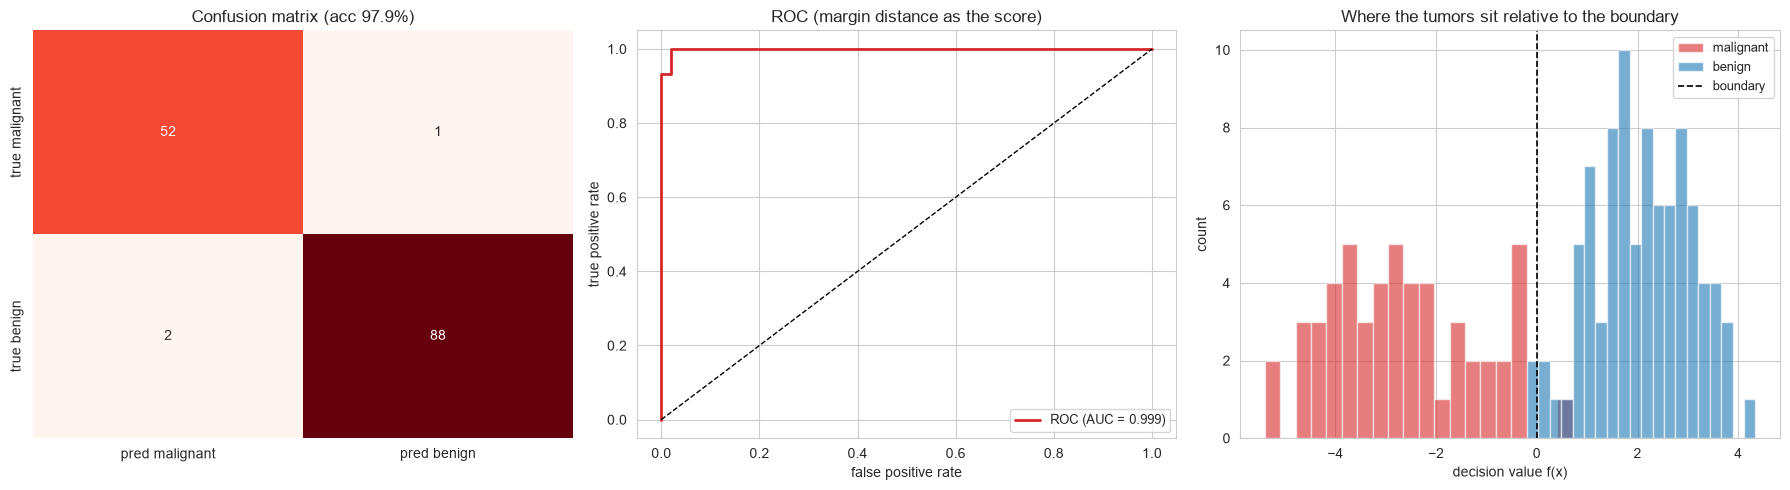

💡 The false-negative cell is the one that matters clinically. A margin distance close to zero flags
   a tumor the model is unsure about. The next cell turns the margin into a calibrated probability.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(ybc_te, pred_bc), annot=True, fmt="d", cmap="Reds", cbar=False,
            ax=axes[0], xticklabels=["pred malignant", "pred benign"],
            yticklabels=["true malignant", "true benign"])
axes[0].set_title(f"Confusion matrix (acc {accuracy_score(ybc_te, pred_bc):.1%})")

fpr_bc, tpr_bc, _ = roc_curve(ybc_te, margin_bc)
axes[1].plot(fpr_bc, tpr_bc, color="#d62728", lw=2,
             label=f"ROC (AUC = {roc_auc_score(ybc_te, margin_bc):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC (margin distance as the score)")
axes[1].legend(fontsize=9)

axes[2].hist(margin_bc[ybc_te == 0], bins=20, alpha=0.6, color="#d62728", label="malignant")
axes[2].hist(margin_bc[ybc_te == 1], bins=20, alpha=0.6, color="#1f77b4", label="benign")
axes[2].axvline(0.0, color="black", ls="--", lw=1.2, label="boundary")
axes[2].set_xlabel("decision value f(x)")
axes[2].set_ylabel("count")
axes[2].set_title("Where the tumors sit relative to the boundary")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("💡 The false-negative cell is the one that matters clinically. A margin distance close to zero flags")
print("   a tumor the model is unsure about. The next cell turns the margin into a calibrated probability.")

### Calibration: Turning Margins into Probabilities You Can Defend

A raw SVM gives margin distances, not probabilities. `CalibratedClassifierCV` with `method="sigmoid"` (Platt scaling) fits a logistic curve to the decision values using cross-validation inside the training split. The reliability diagram checks whether a predicted 70% really means about 70%.

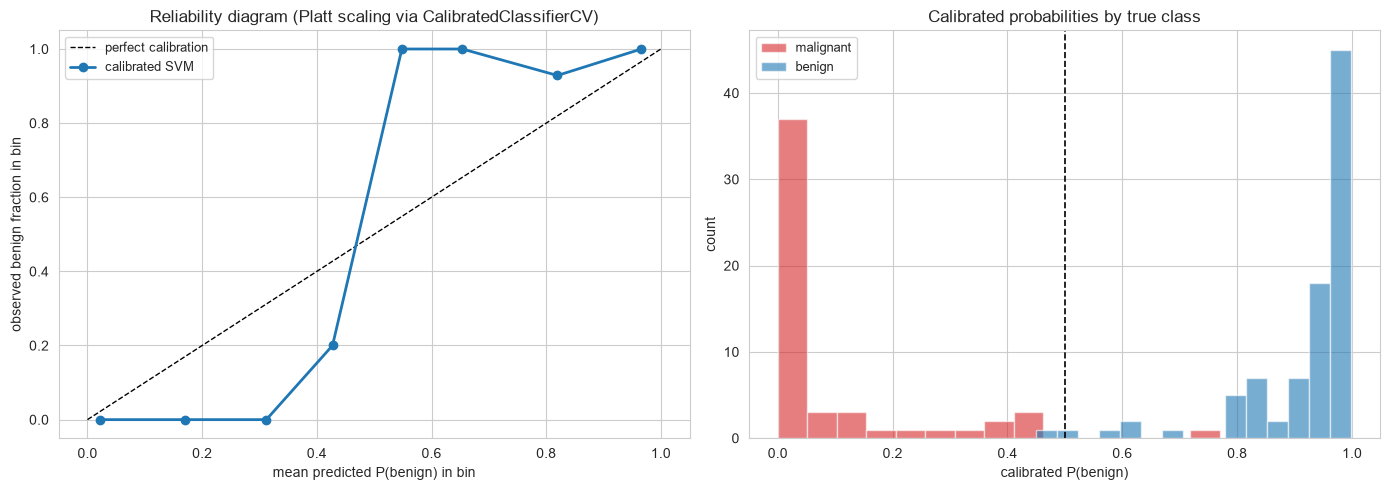

Brier score (calibrated, lower is better): 0.0242
Accuracy at the calibrated 0.5 threshold:  0.9860

💡 Calibration turns margin distances into probabilities you can price or threshold. A sigmoid is
   monotone, so it mostly preserves the ranking. Read the reliability diagram before trusting the numbers.


In [23]:
cal_bc = CalibratedClassifierCV(bc_best, method="sigmoid", cv=5).fit(Xbc_tr, ybc_tr)
proba_benign = cal_bc.predict_proba(Xbc_te)[:, 1]          # calibrated P(benign)
frac_cal, mean_cal = calibration_curve(ybc_te, proba_benign, n_bins=8, strategy="uniform")
brier_cal = brier_score_loss(ybc_te, proba_benign)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[0].plot(mean_cal, frac_cal, "o-", color="#1f77b4", lw=2, label="calibrated SVM")
axes[0].set_xlabel("mean predicted P(benign) in bin")
axes[0].set_ylabel("observed benign fraction in bin")
axes[0].set_title("Reliability diagram (Platt scaling via CalibratedClassifierCV)")
axes[0].legend(fontsize=9)

axes[1].hist(proba_benign[ybc_te == 0], bins=15, alpha=0.6, color="#d62728", label="malignant")
axes[1].hist(proba_benign[ybc_te == 1], bins=15, alpha=0.6, color="#1f77b4", label="benign")
axes[1].axvline(0.5, color="black", ls="--", lw=1.2)
axes[1].set_xlabel("calibrated P(benign)")
axes[1].set_ylabel("count")
axes[1].set_title("Calibrated probabilities by true class")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Brier score (calibrated, lower is better): {brier_cal:.4f}")
print(f"Accuracy at the calibrated 0.5 threshold:  {accuracy_score(ybc_te, (proba_benign >= 0.5).astype(int)):.4f}")
print("\n💡 Calibration turns margin distances into probabilities you can price or threshold. A sigmoid is")
print("   monotone, so it mostly preserves the ranking. Read the reliability diagram before trusting the numbers.")

### Example 2: Handwritten Digits (10 Classes, One-vs-One)

The digits dataset has 1,797 images of 8×8 pixels, so each sample is 64 numeric features. There are ten classes. `SVC` solves this with one-vs-one: one binary classifier for every pair of digits, 45 in total, and each sees only the rows of its two classes. The per-digit support-vector counts show which digits the model finds hardest to separate.

In [24]:
digits = load_digits()
Xd, yd = digits.data, digits.target
idx_all = np.arange(len(yd))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.25, stratify=yd, random_state=42)
Xd_tr, Xd_te, yd_tr, yd_te = Xd[idx_tr], Xd[idx_te], yd[idx_tr], yd[idx_te]

print("=" * 60)
print("REAL-WORLD EXAMPLE: HANDWRITTEN DIGITS (ONE-VS-ONE SVM)")
print("=" * 60)
print(f"\n📊 {Xd.shape[0]} images × {Xd.shape[1]} pixels (8×8), {len(np.unique(yd))} classes")
print(f"   Train/test: {len(yd_tr)} / {len(yd_te)} (stratified)")

digit_grid = GridSearchCV(
    Pipeline([("sc", StandardScaler()), ("svc", SVC(kernel="rbf"))]),
    {"svc__C": [1.0, 10.0, 100.0], "svc__gamma": ["scale", 0.01]},
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
)
digit_grid.fit(Xd_tr, yd_tr)
digit_best = digit_grid.best_estimator_
pred_d = digit_best.predict(Xd_te)

print(f"\n✨ Best parameters: {digit_grid.best_params_}")
print(f"✨ Best CV accuracy: {digit_grid.best_score_:.4f}")
print(f"\n📊 Test accuracy: {accuracy_score(yd_te, pred_d):.4f}")
print(classification_report(yd_te, pred_d, digits=3))

svc_d = digit_best.named_steps["svc"]
print("🔍 Support vectors per digit class (a digit that needs many support vectors is often one that sits close to others):")
for digit_label, count in enumerate(svc_d.n_support_):
    print(f"  digit {digit_label}: {count}")

REAL-WORLD EXAMPLE: HANDWRITTEN DIGITS (ONE-VS-ONE SVM)

📊 1797 images × 64 pixels (8×8), 10 classes
   Train/test: 1347 / 450 (stratified)

✨ Best parameters: {'svc__C': 100.0, 'svc__gamma': 0.01}
✨ Best CV accuracy: 0.9762

📊 Test accuracy: 0.9822
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        45
           1      0.957     0.978     0.968        46
           2      1.000     1.000     1.000        44
           3      1.000     1.000     1.000        46
           4      0.957     0.978     0.967        45
           5      1.000     0.978     0.989        46
           6      0.978     1.000     0.989        45
           7      0.957     1.000     0.978        45
           8      1.000     0.930     0.964        43
           9      0.977     0.956     0.966        45

    accuracy                          0.982       450
   macro avg      0.983     0.982     0.982       450
weighted avg      0.983     0.982     0.982   

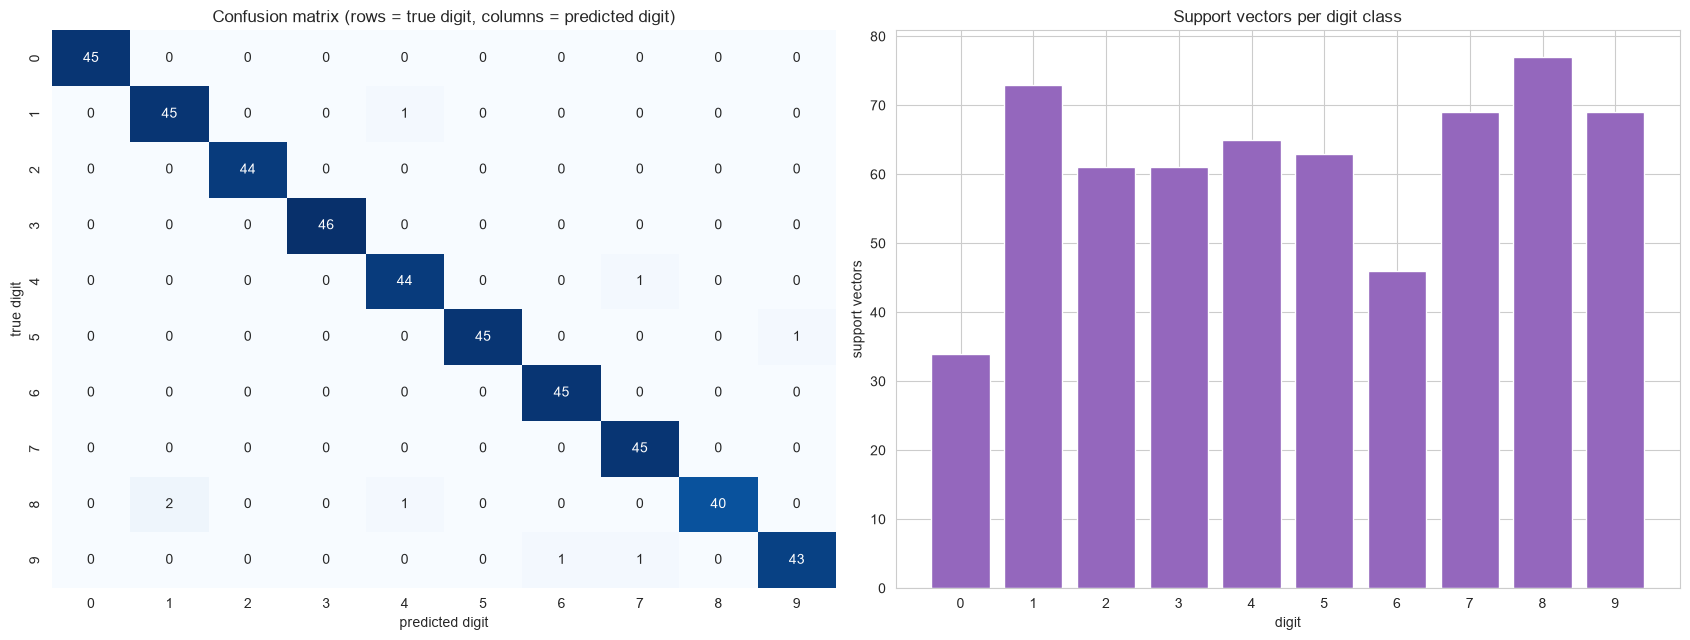

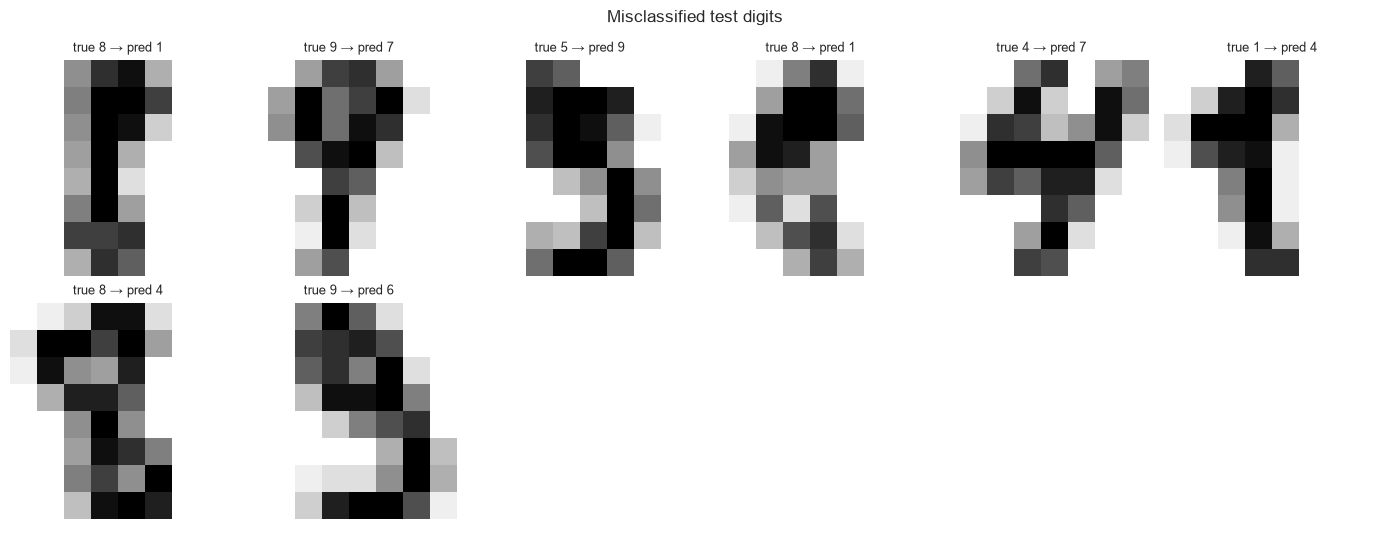

Misclassified test images: 8 of 450

💡 The confusion matrix shows which digit pairs get mixed up. Inspect the misclassified images and ask
   whether a person would have made the same call. That is a useful reality check on the accuracy number.


In [25]:
cm_d = confusion_matrix(yd_te, pred_d)
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Confusion matrix (rows = true digit, columns = predicted digit)")
axes[0].set_xlabel("predicted digit")
axes[0].set_ylabel("true digit")

axes[1].bar(range(10), svc_d.n_support_, color="#9467bd")
axes[1].set_xticks(range(10))
axes[1].set_xlabel("digit")
axes[1].set_ylabel("support vectors")
axes[1].set_title("Support vectors per digit class")
plt.tight_layout()
plt.show()

wrong_pos = np.flatnonzero(pred_d != yd_te)[:12]
fig2, axes2 = plt.subplots(2, 6, figsize=(14, 5.5))
for ax_m, pos in zip(axes2.ravel(), wrong_pos):
    ax_m.imshow(digits.images[idx_te[pos]], cmap="gray_r")
    ax_m.set_title(f"true {yd_te[pos]} → pred {pred_d[pos]}", fontsize=9)
    ax_m.axis("off")
for ax_m in axes2.ravel()[len(wrong_pos):]:
    ax_m.axis("off")
fig2.suptitle("Misclassified test digits")
plt.tight_layout()
plt.show()

print(f"Misclassified test images: {len(np.flatnonzero(pred_d != yd_te))} of {len(yd_te)}")
print("\n💡 The confusion matrix shows which digit pairs get mixed up. Inspect the misclassified images and ask")
print("   whether a person would have made the same call. That is a useful reality check on the accuracy number.")

---

## 11. Comparison with Other Algorithms

### When to Choose an SVM vs Alternatives

| Aspect | SVM (RBF) | Logistic Regression | Decision Tree | Random Forest | Gaussian NB |
|---|---|---|---|---|---|
| **Interpretability** | ⭐ (support vectors) | ⭐⭐⭐⭐⭐ (odds ratios) | ⭐⭐⭐⭐ (visual) | ⭐⭐ | ⭐⭐⭐ |
| **Training Speed** | ⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Prediction Speed** | ⭐⭐⭐ (scales with support vectors) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Non-linear Boundaries** | ⭐⭐⭐⭐⭐ (kernel) | ⭐ (transform-fixable) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Probability Quality** | ⭐⭐ (needs calibration) | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ (often overconfident) |
| **Feature Scaling Needed** | ✅ | ✅ (for speed and odds) | ❌ | ❌ | ❌ |
| **Large n** | ❌ with RBF, ✅ with linear solvers | ✅ | ✅ | ✅ | ✅ |
| **Small Data** | ⭐⭐⭐⭐ (with tuning) | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Sparse High-dimensional** | ⭐⭐⭐⭐ (linear kernel) | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |

The **kernel row** is where the SVM earns its place: it bends boundaries that logistic regression cannot, with fewer structural assumptions than a tree needs. The **training-speed and large-n rows** are its cost. Its sparsity (only support vectors matter) is real but does not change training cost.

### Practical Comparison

The same CV protocol on three geometries: blobs (separable), moons (interleaved), and the real breast cancer data. Every model sees the same scaled features where scaling matters. Tree-based models see raw features.

ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES
Dataset              Blobs (separable)  Breast cancer (real)  Moons (interleaved)
Algorithm                                                                        
Gaussian NB                      0.960                0.9385                0.852
KNN (k=7)                        0.968                0.9649                0.966
Linear SVM (SVC)                 0.962                0.9737                0.850
Logistic Regression              0.960                0.9737                0.860
RBF SVM (SVC)                    0.960                0.9772                0.958
Random Forest                    0.962                0.9543                0.962

             Dataset           Algorithm  CV accuracy  ± std  CV time (s)
   Blobs (separable) Logistic Regression       0.9600 0.0089       0.0266
   Blobs (separable)    Linear SVM (SVC)       0.9620 0.0075       0.0129
   Blobs (separable)       RBF SVM (SVC)       0.9600 0.0089

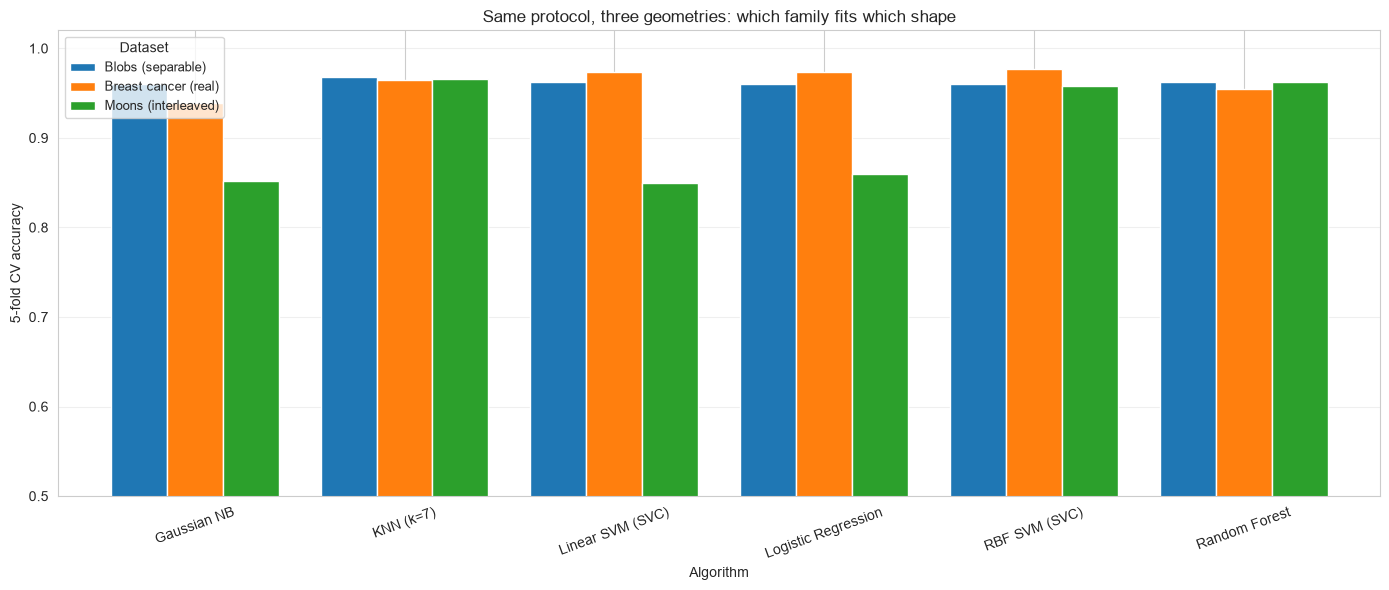


💡 Read the three geometries together. A linear model is enough where the classes are separable by a line.
   The RBF SVM earns its place on the interleaved geometry. Check the real-data column before generalizing.


In [26]:
bc3 = load_breast_cancer()
datasets_cmp = {
    "Blobs (separable)": make_blobs(n_samples=500, centers=2, cluster_std=2.8, random_state=42),
    "Moons (interleaved)": make_moons(n_samples=500, noise=0.22, random_state=42),
    "Breast cancer (real)": (bc3.data, bc3.target),
}


def cmp_estimators():
    return {
        "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                         ("clf", LogisticRegression(max_iter=2000))]),
        "Linear SVM (SVC)": Pipeline([("sc", StandardScaler()),
                                      ("clf", SVC(kernel="linear", C=1.0))]),
        "RBF SVM (SVC)": Pipeline([("sc", StandardScaler()),
                                   ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
        "KNN (k=7)": Pipeline([("sc", StandardScaler()),
                               ("clf", KNeighborsClassifier(n_neighbors=7))]),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        "Gaussian NB": GaussianNB(),
    }


rows_bench = []
cv_bench = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for dname, (Xd_b, yd_b) in datasets_cmp.items():
    for ename, est in cmp_estimators().items():
        t0 = time.perf_counter()
        scores_b = cross_val_score(est, Xd_b, yd_b, cv=cv_bench, scoring="accuracy", n_jobs=-1)
        t_b = time.perf_counter() - t0
        rows_bench.append({"Dataset": dname, "Algorithm": ename,
                           "CV accuracy": scores_b.mean(), "± std": scores_b.std(),
                           "CV time (s)": t_b})
bench_df = pd.DataFrame(rows_bench)

pivot_bench = bench_df.pivot(index="Algorithm", columns="Dataset", values="CV accuracy")
print("=" * 60)
print("ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES")
print("=" * 60)
print(pivot_bench.round(4).to_string())
print()
print(bench_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(14, 6))
pivot_bench.plot(kind="bar", ax=ax, rot=20, width=0.8)
ax.set_ylabel("5-fold CV accuracy")
ax.set_ylim(0.5, 1.02)
ax.set_title("Same protocol, three geometries: which family fits which shape")
ax.legend(title="Dataset", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Read the three geometries together. A linear model is enough where the classes are separable by a line.")
print("   The RBF SVM earns its place on the interleaved geometry. Check the real-data column before generalizing.")

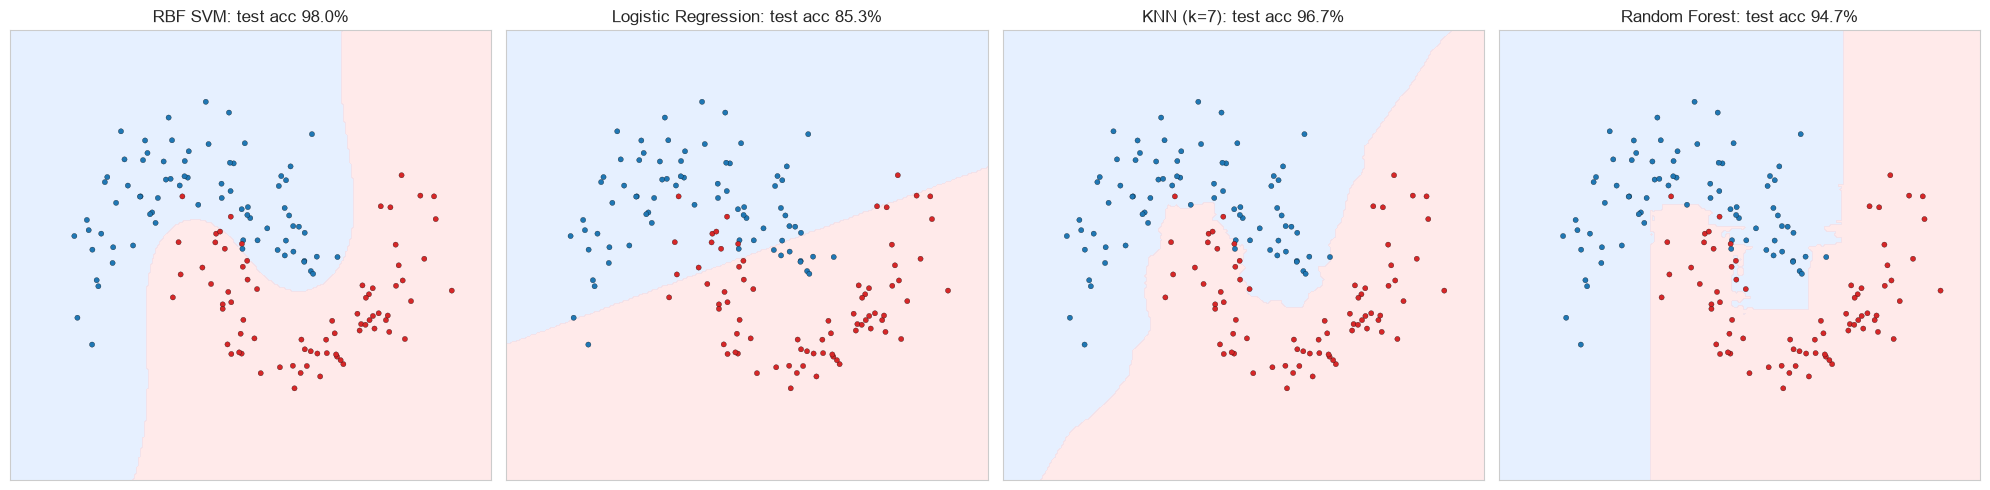

💡 The RBF boundary follows the crescents. The logistic boundary is one straight line by construction.
   KNN and the forest carve the data locally. The printed accuracies show how that compares here.


In [27]:
# The same four families on the moons geometry: the boundary shapes behind the numbers
X_mo, y_mo = make_moons(n_samples=500, noise=0.22, random_state=42)
Xmo_tr, Xmo_te, ymo_tr, ymo_te = train_test_split(X_mo, y_mo, test_size=0.3,
                                                  stratify=y_mo, random_state=42)
families_mo = {
    "RBF SVM": Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
    "KNN (k=7)": Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=7))]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

pad_mo = 0.4
xx_mo, yy_mo = np.meshgrid(
    np.linspace(X_mo[:, 0].min() - pad_mo, X_mo[:, 0].max() + pad_mo, 250),
    np.linspace(X_mo[:, 1].min() - pad_mo, X_mo[:, 1].max() + pad_mo, 250),
)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, est) in zip(axes, families_mo.items()):
    est.fit(Xmo_tr, ymo_tr)
    Z_mo = est.predict(np.c_[xx_mo.ravel(), yy_mo.ravel()]).reshape(xx_mo.shape)
    ax.contourf(xx_mo, yy_mo, Z_mo, levels=[-0.5, 0.5, 1.5], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    ax.scatter(Xmo_te[:, 0], Xmo_te[:, 1], c=np.where(ymo_te == 1, "#d62728", "#1f77b4"),
               s=14, edgecolors="k", linewidths=0.2)
    ax.set_title(f"{name}: test acc {est.score(Xmo_te, ymo_te):.1%}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

print("💡 The RBF boundary follows the crescents. The logistic boundary is one straight line by construction.")
print("   KNN and the forest carve the data locally. The printed accuracies show how that compares here.")

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - Vapnik, V., & Lerner, A. (1963). "Pattern recognition using generalized portrait method." *Automation and Remote Control*, 24: the maximum-margin idea
   - **Boser, B. E., Guyon, I. M., & Vapnik, V. N. (1992). "A Training Algorithm for Optimal Margin Classifiers."** *COLT '92*: the kernel trick applied to margin classifiers
   - **Cortes, C., & Vapnik, V. (1995). "Support-Vector Networks."** *Machine Learning*, 20(3): the soft-margin formulation used today
2. **Solvers**:
   - **Platt, J. C. (1998). "Sequential Minimal Optimization: A Fast Algorithm for Training Support Vector Machines."** Microsoft Research Technical Report MSR-TR-98-14
   - Keerthi, S. S., Shevade, S. K., Bhattacharyya, C., & Murthy, K. R. K. (2001). "Improvements to Platt's SMO Algorithm for SVM Classifier Design." *Neural Computation*, 13(3)
   - **Chang, C.-C., & Lin, C.-J. (2011). "LIBSVM: A Library for Support Vector Machines."** *ACM TIST*, 2(3): the library behind `SVC`
   - Fan, R.-E., Chang, K.-W., Hsieh, C.-J., Wang, X.-R., & Lin, C.-J. (2008). "LIBLINEAR: A Library for Large Linear Classification." *JMLR*, 9: the library behind `LinearSVC`
3. **Practical Guides and Tutorials**:
   - Hsu, C.-W., Chang, C.-C., & Lin, C.-J. (2003). "A Practical Guide to Support Vector Classification." National Taiwan University technical report: scaling, grid search, and the `C` and `gamma` recipe
   - Burges, C. J. C. (1998). "A Tutorial on Support Vector Machines for Pattern Recognition." *Data Mining and Knowledge Discovery*, 2(2)
4. **Probabilities**:
   - Platt, J. C. (1999). "Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods." In *Advances in Large Margin Classifiers*, MIT Press: the sigmoid calibration behind `CalibratedClassifierCV(method='sigmoid')`
5. **Modern Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapter 12 (Support Vector Machines and Flexible Discriminants)
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapter 7 (Sparse Kernel Machines)
   - Schölkopf, B., & Smola, A. J. (2002). *Learning with Kernels*. MIT Press: the kernel theory in depth
   - Cristianini, N., & Shawe-Taylor, J. (2000). *An Introduction to Support Vector Machines and Other Kernel-based Learning Methods*. Cambridge University Press
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*, Chapter 9 (free PDF at statlearning.com)

### 🌐 Online Resources

- [Scikit-learn SVM user guide](https://scikit-learn.org/stable/modules/svm.html): the main reference for `SVC`, `LinearSVC`, and `SVR`
- [SVC API reference](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
- [LinearSVC API reference](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)
- [Probability calibration guide](https://scikit-learn.org/stable/modules/calibration.html): the guide behind §10 Example 1
- [LIBSVM homepage](https://www.csie.ntu.edu.tw/~cjlin/libsvm/)
- StatQuest's SVM videos on YouTube (search "StatQuest support vector machines"): the intuition for margins and kernels

### 📊 Key Concepts to Master

- **Maximum margin**: the boundary maximizes $2/\|w\|$; only the points on or inside the band matter
- **Hinge loss**: $\max(0, 1 - y f(x))$, zero beyond the margin, which produces sparsity
- **Dual and support vectors**: $\alpha_i > 0$ marks a support vector, and $0 \le \alpha_i \le C$
- **Kernel trick**: inner products in a feature space without building it; RBF has an infinite-dimensional feature space
- **C and γ**: C penalizes violations, γ sets the RBF width. They interact, so tune them together on a log grid
- **Scaling**: mandatory, because every kernel is built from distances
- **Multiclass**: one-vs-one inside `SVC` and one-vs-rest inside `LinearSVC`
- **Probabilities**: not native. Calibrate with `CalibratedClassifierCV` before using them as risk

### 🔗 Related Notebooks and Repository Files

- `02_logistic_regression.ipynb`: the probabilistic linear counterpart, with odds ratios and calibration
- `03_decision_trees.ipynb`: the local, axis-aligned alternative that needs no scaling
- `04_random_forest.ipynb`: the ensemble alternative with smoother probability estimates
- `06_naive_bayes.ipynb`: the fast generative alternative
- `07_k_nearest_neighbors.ipynb`: the instance-based alternative that stores the whole training set
- `src/models/svm_models.py`: the from-scratch twin used in §5
- `tests/models/test_svm_models.py`: the behavioral tests that pin down the twin's conventions (decision sign, one-vs-one aggregation, label handling, validation)

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: an SVM maximizes the margin $2/\|w\|$. A hinge-loss penalty $C$ controls violations, and the solution depends only on the support vectors
2. **Math**: the dual $\max \sum_i \alpha_i - \tfrac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j K(x_i, x_j)$ with $0 \le \alpha_i \le C$. The decision function is $f(x) = \sum_{sv} \alpha_i y_i K(x_i, x) + b$
3. **Kernel trick**: RBF $\exp(-\gamma\|x - x'\|^2)$ bends the boundary without explicit features. γ sets the width and C sets the tolerance
4. **Assumptions**: scale the features, keep the data complete, choose a kernel that matches the geometry, and watch the sample size
5. **Implementation**: the twin is simplified SMO with a deterministic partner ladder and closed-form pair updates. scikit-learn's `SVC` wraps libSVM
6. **Hyperparameters**: C and γ on log grids for RBF, kernel as a shape choice, `class_weight` for imbalance, and a threshold chosen from out-of-fold scores
7. **Practice**: breast cancer with a scaled pipeline, CV tuning, and calibration for probabilities. Digits with one-vs-one and per-class support vectors

### When to Use an SVM

✅ **Use when**:
- features are numeric, scaled, and clean, with a margin structure between classes
- the data is high-dimensional with moderate n (text, gene expression, image features)
- you want a sparse model and a strong baseline with few knobs
- the boundary is curved and n stays within the practical range of an exact kernel

❌ **Avoid when**:
- n is very large and the kernel is required. Use `LinearSVC`, SGD, boosting, or an approximate kernel
- calibrated probabilities are the core product. Logistic regression is simpler
- per-feature explanations are required under a non-linear kernel
- the model must update incrementally on a stream

### Best Practices Checklist

- ✅ scale inside a `Pipeline` so the scaler sees only training data
- ✅ tune C and γ on log grids with stratified CV
- ✅ run a linear baseline before the RBF model
- ✅ report per-class metrics and choose the metric before the model
- ✅ choose the threshold on out-of-fold scores, then check the test set once
- ✅ calibrate before treating margins as risk
- ✅ use the solver's health checks: `n_iter_`, the support-vector fraction, and convergence warnings

### Critical Requirements

1. **Scaled, complete numeric features**. Impute and one-hot encode first
2. **Binary natively**; multiclass one-vs-one (`SVC`) or one-vs-rest (`LinearSVC`)
3. **Enough rows for the kernel to pin the boundary**, and memory for the Gram matrix at scale
4. **A tuning budget for C and γ**. Without it, the SVM can underperform a simple baseline

### Advantages vs Disadvantages

**Advantages:**
- ✅ strong accuracy on clean, scaled data
- ✅ margin maximization gives robust boundaries
- ✅ sparse solution: only support vectors matter
- ✅ the kernel bends boundaries without hand-built features
- ✅ mature solvers (libSVM and liblinear)

**Disadvantages:**
- ❌ training cost grows super-linearly with n for kernel SVMs
- ❌ sensitive to scaling and to C and γ
- ❌ no native probabilities
- ❌ RBF models are hard to interpret in the original features
- ❌ prediction cost grows with the number of support vectors

### Unique Characteristic: The Margin

An SVM does not ask "how likely?" It asks "how far from the boundary, relative to the margin?" Only the points near the boundary decide the answer. That is why it is robust and sparse, and why its outputs need calibration before anyone treats them as risk.

### Next Steps

1. **Practice** on your own data: a linear baseline, then RBF on a log grid, then calibration if the decision consumes probabilities
2. **Diagnose**: the train-test gap, the support-vector fraction, `n_iter_` against `max_iter`, and convergence warnings
3. **Compare** with logistic regression and boosting on the same scaled features (§11 style)
4. **Read** notebook 02 for the probabilistic alternative and notebook 04 for ensembles
5. **Explore** `tests/models/test_svm_models.py` to see which behaviors the scratch twin pins down

---

**Congratulations!** You can now explain the margin, read a support vector off a fitted model, tune C and γ on a log grid, and know when a kernel machine is the wrong tool. 🎯🎉

**Remember**: the boundary is decided by the few points nearest to it. Scale your features, tune on training data only, and calibrate before you put a margin on a decision.